# Notebook for Making Figures for Frame 5.

## Prepare the notebook.

### Import Libraries.

In [1]:
import math
import os
import sys
import yaml

import hydra
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_forward_model, generate_with_condition, generated_density_knn, get_adata_from_idx


### Define Color Palette for Cell Types.

In [2]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'late_MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

### Read Annotation Configurations.

In [3]:
config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config_path, "r") as fb:
    annot_dict = yaml.safe_load(fb)
protocol_cols = annot_dict["protocol_columns"]

### Read Constraints File.

In [4]:
constraints_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]


### Load Configurations.

In [5]:
with hydra.initialize(
    config_path="../../inverse/loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )

/tmp/ipykernel_2189625/10581362.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


## Load Data.

### Load Annotated Data without LPHO012 Experiment.

In [6]:
path_adata_old = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_old_experiments_.h5ad"
adata_old = sc.read_h5ad(path_adata_old)
adata_old

AnnData object with n_obs × n_vars = 449218 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Annotated Data with LPHO012 Experiment.

In [7]:
path_adata_new = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
adata_new = sc.read_h5ad(path_adata_new)
adata_new.uns["cell_type_colors"] = color_map
adata_new

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Full Adata without LPHO012.

In [ ]:
path_adata_full_old = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad"
adata_full_old = sc.read_h5ad(path_adata_full_old)
adata_full_old

### Load Full Adata with LPHO012.

In [ ]:
path_adata_full = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad"
adata_full = sc.read_h5ad(path_adata_full)
adata_full

AnnData object with n_obs × n_vars = 52085765 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Prepare Unique Real Conditions.

In [ ]:
# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_conds = adata_full.obs[protocol_cols].astype(float).values   # or use obs[protocol_columns].values
exp_nums = adata_full.obs["experiment_number"].values

# Get unique condition per experiment
unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]   # all cells in same exp share the same condition
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
exp_labels = np.array(exp_labels)


## Panel A: UMAP Plot of Old Data, Highlighting MgkPro cells.

Updated color for late_MgkPro to #3a4f6a


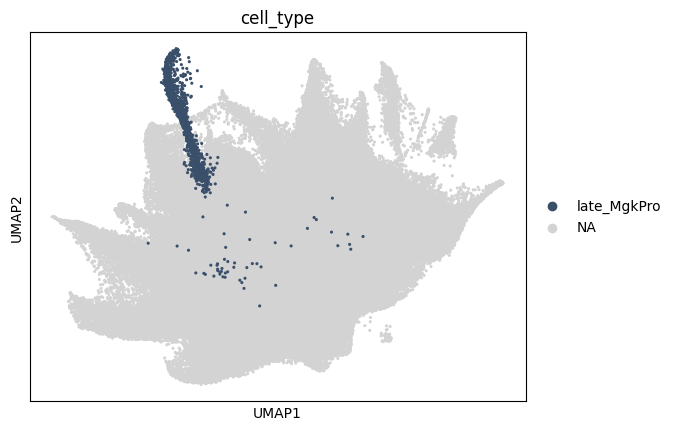

In [77]:
# Ensure the uns entry is a list (recreate if it's broken)
if not isinstance(adata_old.uns.get('cell_type_colors'), list):
    categories = adata_old.obs['cell_type'].cat.categories
    # Use existing colors if available, otherwise a default grey
    old_colors = adata_old.uns.get('cell_type_colors', {})
    adata_old.uns['cell_type_colors'] = [
        old_colors.get(ct, '#cccccc') if isinstance(old_colors, dict) else '#cccccc'
        for ct in categories
    ]

# Now update only the color for 'MgkPro' (exact category name)
cell_type_colors = adata_old.uns['cell_type_colors']
categories = adata_old.obs['cell_type'].cat.categories.tolist()

target_cell = 'late_MgkPro'   # or 'late_MgkPro' if that's the exact name in your data
if target_cell in categories:
    idx = categories.index(target_cell)
    cell_type_colors[idx] = '#3a4f6a'   # from your map
    print(f"Updated color for {target_cell} to #3a4f6a")
else:
    print(f"'{target_cell}' not found in categories. Available: {categories}")


sc.pl.umap(adata_old, color="cell_type", s=20, groups=["late_MgkPro"], show=False)

# Save high-quality figure
plt.savefig(
    'output/umap_late_MgkPro_old_data.png',      # or .svg, .png
    dpi=300,                                      # for raster formats
    bbox_inches='tight',                          # removes excess white space
    facecolor='white'                             # ensures white background
)                    

# Optional: show plot (if desired) before or after saving
plt.show()

## Panel B: Frequency of Late MgkPro Across Conditions.

### Compute Proportions.

In [78]:
# get unique concentrations
unique_concs = np.unique(adata_old.obs[protocol_cols].astype(float).values, axis=0)
concs_df = pd.DataFrame(unique_concs, columns=protocol_cols)

# compute proportions
props = []
for idx, row in tqdm(concs_df.iterrows()):
    # slice adata for current experiment
    row_vals = row.values
    rmask = np.all(adata_old.obs[protocol_cols].astype(float).values == row_vals, axis=1)
    radata = adata_old[rmask]
    nexp = rmask.sum()

    # compute conts of MgkPro
    ct_mask = radata.obs.cell_type == "late_MgkPro"
    n_ct = ct_mask.sum()

    # proportion
    ct_prop = (n_ct / nexp).item()
    props.append(ct_prop)
concs_df["late_MgkPro_prop"] = props
concs_df["condition"] = np.arange(len(concs_df))

97it [00:03, 25.53it/s]


### Plot.

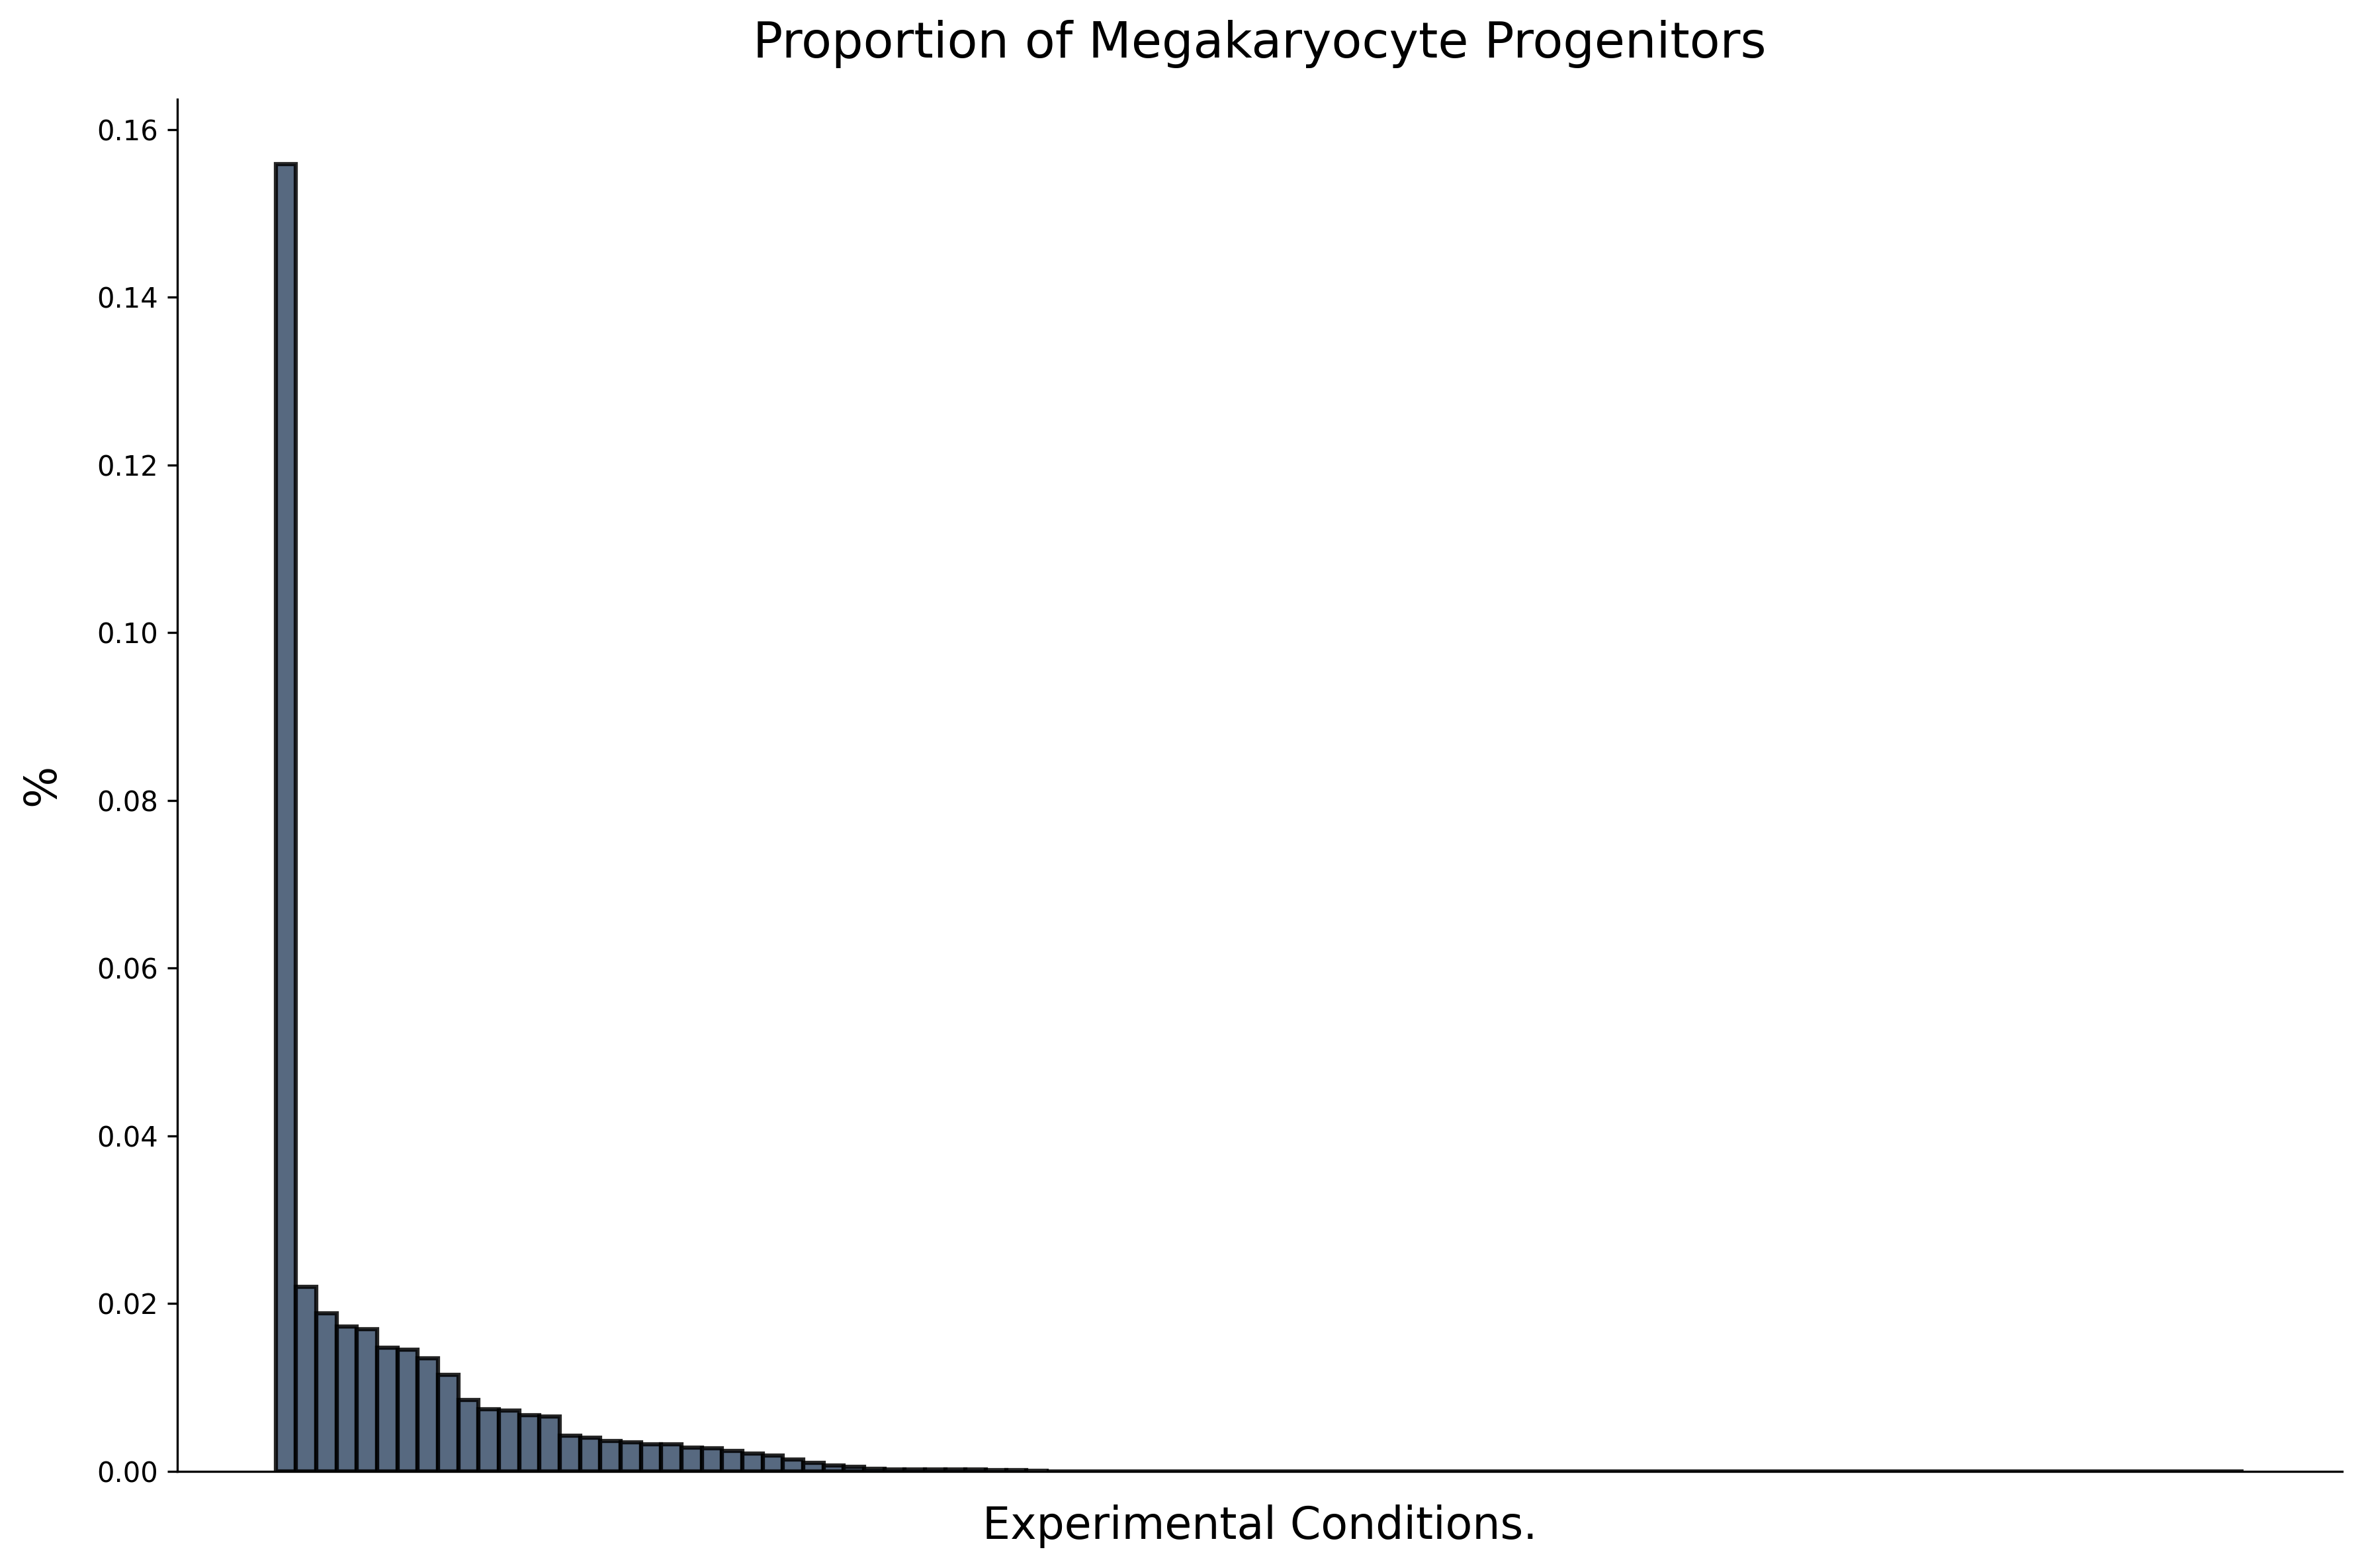

In [82]:
# ----- Make bars MAXIMUM size -----
# Increase figure width dramatically (e.g., 20 inches wide, 8 inches tall)
# Adjust numbers to your preference: more width = thicker bars

color = color_map["late_MgkPro"]

plt.figure(figsize=(12, 8), dpi=300)        # much wider figure

concs_df_sorted = concs_df.sort_values('late_MgkPro_prop', ascending=False).reset_index(drop=True)
x_values = range(len(concs_df_sorted))

ax = plt.bar(x_values, concs_df_sorted['late_MgkPro_prop'],
             width=1.0,                      # bars touching → maximum width per bar
             color=color,
             edgecolor='black',
             linewidth=1.5,
             alpha=0.85)

# Remove x‑ticks completely
plt.xticks([], [])
plt.tick_params(axis='x', which='both', length=0)

# Labels and title (larger fonts for big figure)
plt.ylabel('%', fontsize=16, labelpad=12)
plt.xlabel('Experimental Conditions.', fontsize=16, labelpad=12)
plt.title('Proportion of Megakaryocyte Progenitors', fontsize=18, pad=15)

sns.despine()
plt.tight_layout()
plt.savefig('output/proportion_late_MgkPro_per_experimental_condition_old_data.png', 
            bbox_inches='tight', dpi=300)
plt.show()


## Panel D: Visualize Candidates without LPHO012.

### Read Candidates Data.

In [ ]:
candidates_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official"
opt_modes_list = os.listdir(candidates_base_dir)

all_records = []
for opt_mode in opt_modes_list:
    opt_mode_base_dir = os.path.join(
        candidates_base_dir, opt_mode, "late_MgkPro"
    )

    runs_list = os.listdir(opt_mode_base_dir)

    for run_id in runs_list:
        candidates_csv_path = os.path.join(opt_mode_base_dir, run_id, "uncertainty_annotation", "candidates_with_uncertainties.csv")
        candidates_csv = pd.read_csv(candidates_csv_path)

        candidates_csv["run"] = run_id
        candidates_csv["opt_mode"] = opt_mode
        
        all_records.append(candidates_csv)
candidates_df = pd.concat(all_records, axis=0)
candidates_df

### Filter out Unfeasible Candidates.

In [ ]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 37200 ---
			 --- Number Currently Accepted Solutions 34785 ---
			 --- Number of Solution Satisfying Upper Bound 34785 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 34785 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 37200 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 34785 ---
			 --- Number Currently Accepted Solutions 30333 ---
			 --- Number of Solution Satisfying Upper Bound 31757 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 30333 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 34785 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

### Filtering Bad Solutions.

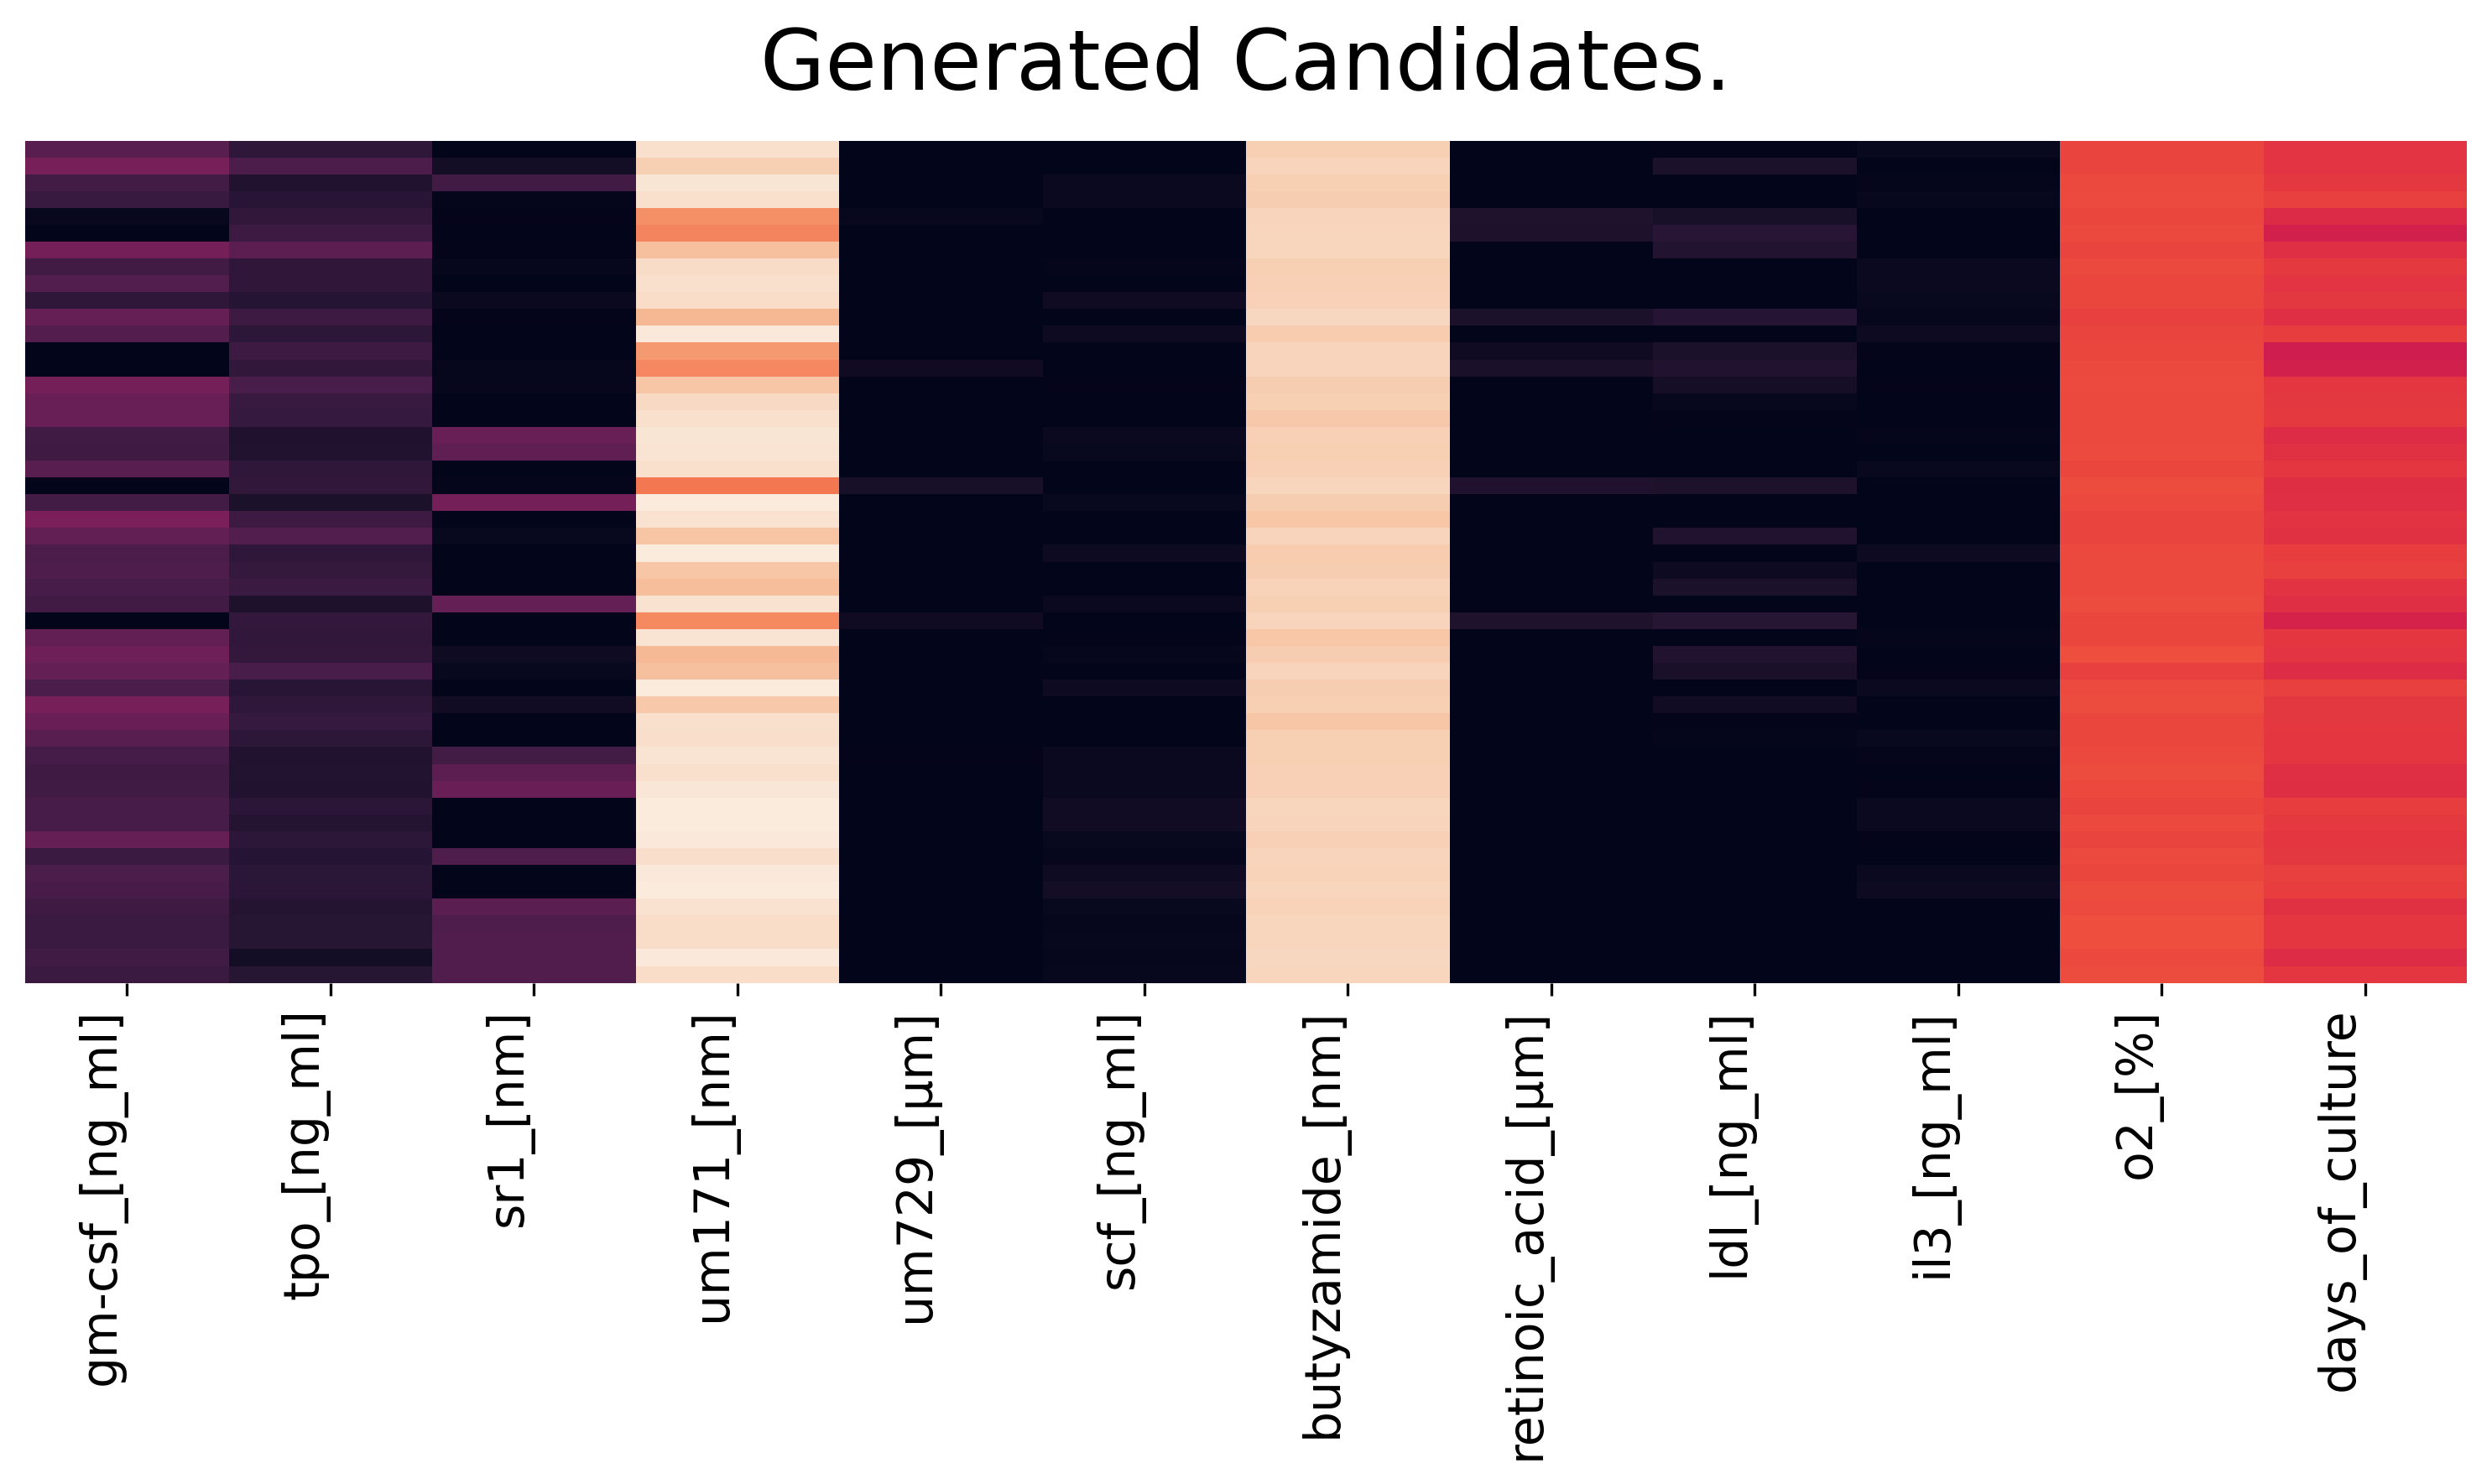

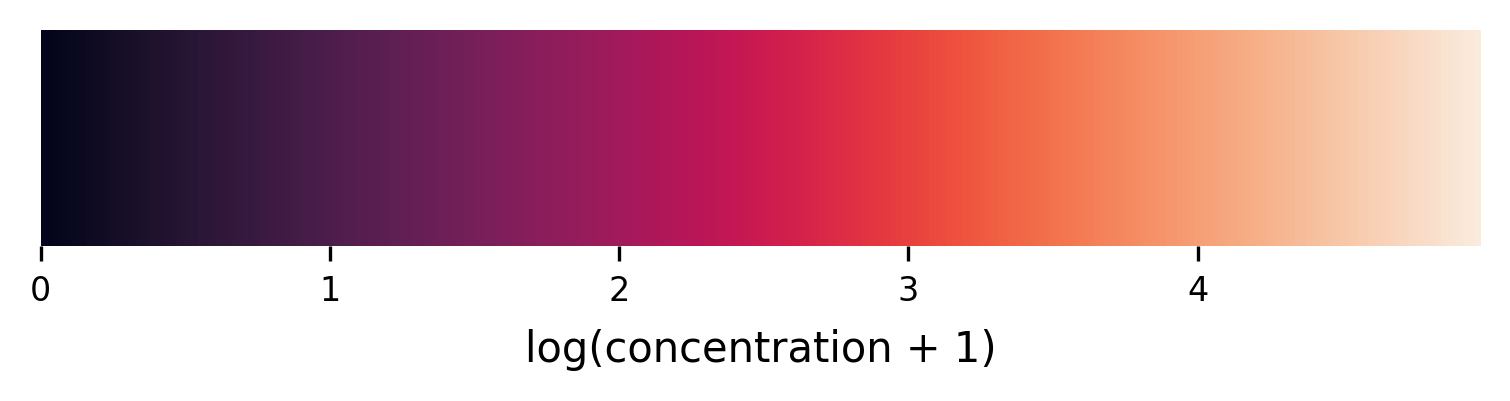

In [ ]:
# ------------------------------------------------------------------
# 1. Prepare the data (unchanged)
# ------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
mgk_enriching_mask = (filtered_candidates_df["late_MgkPro_prop"] > 0.15)
filtered_candidates_df = filtered_candidates_df[mgk_enriching_mask]
filtered_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1))

# Determine global min/max for consistent colour scaling
vmin = filtered_concs.min().min()
vmax = filtered_concs.max().max()
cmap = 'rocket'  # or 'plasma', 'rocket', etc. – match your heatmap

# ------------------------------------------------------------------
# 2. Main heatmap (without colorbar)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=300)
ax = sns.heatmap(
    filtered_concs,
    annot=False,
    fmt='.2f',
    linewidths=0.0,
    linecolor='black',
    cbar=False,               # disable the built‑in colorbar
    vmin=vmin, vmax=vmax,
    cmap=cmap
)

# Remove y‑axis ticks and labels
ax.set_yticklabels([])
ax.tick_params(axis='y', left=False)

# Rotate x‑labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=14)

# Add title
plt.title('Generated Candidates.', fontsize=24, pad=15)

plt.tight_layout()
plt.savefig('output/filtered_concentrations_heatmap_old_data.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# 3. Save the colorbar separately (fat and short, horizontal)
# ------------------------------------------------------------------
fig_cbar = plt.figure(figsize=(6, 1.2), dpi=300)   # wide and short
ax_cbar = fig_cbar.add_axes([0.1, 0.2, 0.8, 0.6])  # [left, bottom, width, height]

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)
cbar.ax.tick_params(labelsize=8)

# Remove the frame around the colorbar axis
ax_cbar.set_frame_on(False)

fig_cbar.savefig('output/heatma_colorbar_separate_old.png', bbox_inches='tight', dpi=300)
plt.show()


## Panel E: Effect of Inclusion of Sakurai Medium. 

### Umap of New Data.

Updated color for late_MgkPro to #3a4f6a


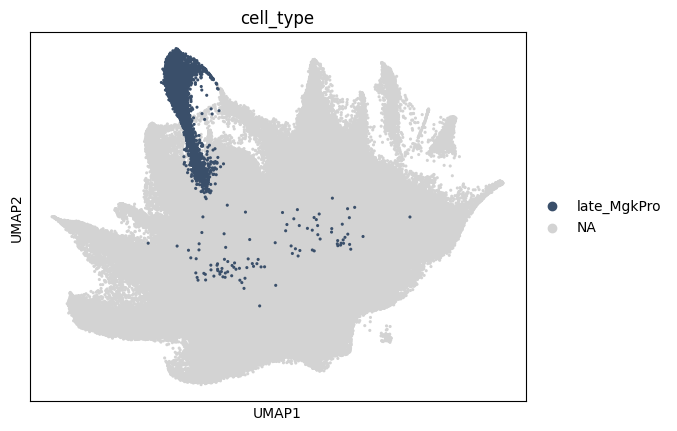

In [ ]:
# Ensure the uns entry is a list (recreate if it's broken)
if not isinstance(adata_new.uns.get('cell_type_colors'), list):
    categories = adata_new.obs['cell_type'].cat.categories
    # Use existing colors if available, otherwise a default grey
    old_colors = adata_new.uns.get('cell_type_colors', {})
    adata_new.uns['cell_type_colors'] = [
        old_colors.get(ct, '#cccccc') if isinstance(old_colors, dict) else '#cccccc'
        for ct in categories
    ]

# Now update only the color for 'MgkPro' (exact category name)
cell_type_colors = adata_new.uns['cell_type_colors']
categories = adata_new.obs['cell_type'].cat.categories.tolist()

target_cell = 'late_MgkPro'   # or 'late_MgkPro' if that's the exact name in your data
if target_cell in categories:
    idx = categories.index(target_cell)
    cell_type_colors[idx] = '#3a4f6a'   # from your map
    print(f"Updated color for {target_cell} to #3a4f6a")
else:
    print(f"'{target_cell}' not found in categories. Available: {categories}")


sc.pl.umap(adata_new, color="cell_type", s=20, groups=["late_MgkPro"], show=False)

# Save high-quality figure
plt.savefig(
    'output/umap_late_MgkPro_new_data.png',      # or .svg, .png
    dpi=300,                                      # for raster formats
    bbox_inches='tight',                          # removes excess white space
    facecolor='white'                             # ensures white background
)                    

# Optional: show plot (if desired) before or after saving
plt.show()

### Frequency of MgkPros Across Conditions.

In [ ]:
# get unique concentrations
unique_concs = np.unique(adata_new.obs[protocol_cols].astype(float).values, axis=0)
concs_df_new = pd.DataFrame(unique_concs, columns=protocol_cols)

# compute proportions
props = []
for idx, row in tqdm(concs_df_new.iterrows()):
    # slice adata for current experiment
    row_vals = row.values
    rmask = np.all(adata_new.obs[protocol_cols].astype(float).values == row_vals, axis=1)
    radata = adata_new[rmask]
    nexp = rmask.sum()

    # compute conts of MgkPro
    ct_mask = radata.obs.cell_type == "late_MgkPro"
    n_ct = ct_mask.sum()

    # proportion
    ct_prop = (n_ct / nexp).item()
    props.append(ct_prop)
concs_df_new["late_MgkPro_prop"] = props
concs_df_new["condition"] = np.arange(len(concs_df_new))

103it [00:02, 35.66it/s]


### Plot Frequency.

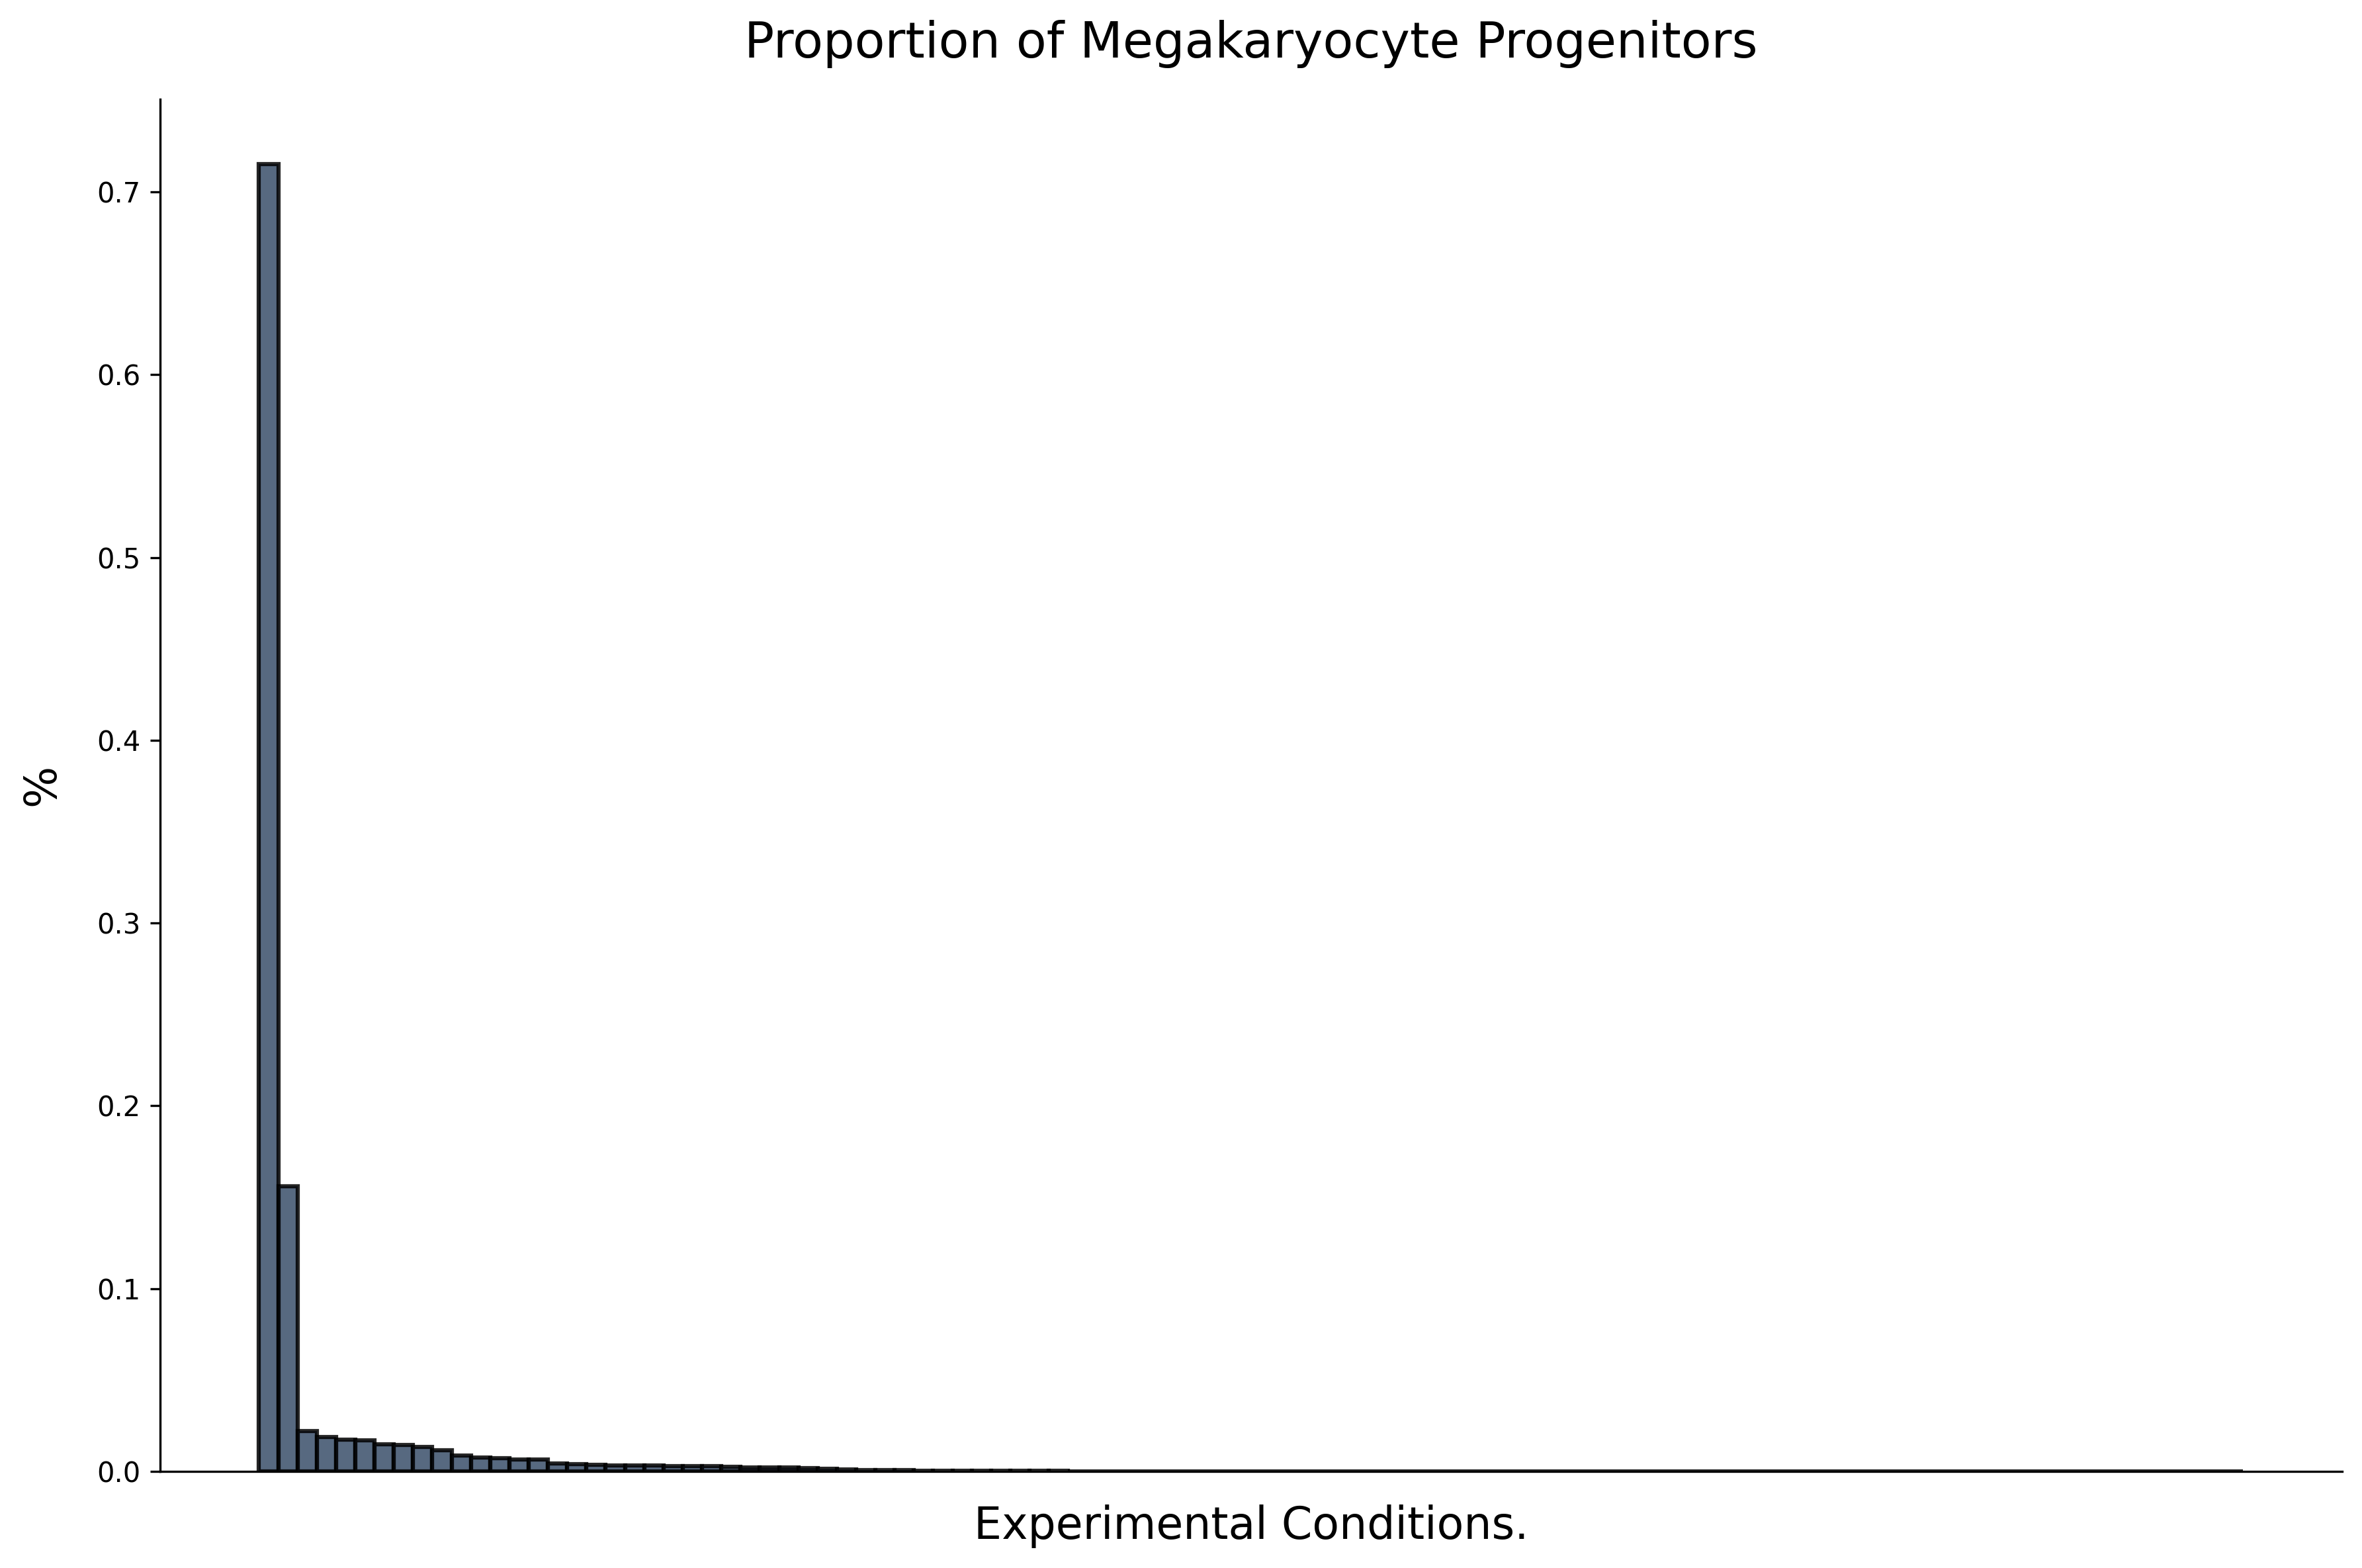

In [ ]:
# ----- Make bars MAXIMUM size -----
# Increase figure width dramatically (e.g., 20 inches wide, 8 inches tall)
# Adjust numbers to your preference: more width = thicker bars

color = color_map["late_MgkPro"]

plt.figure(figsize=(12, 8), dpi=300)        # much wider figure
concs_df_sorted = concs_df_new.sort_values('late_MgkPro_prop', ascending=False).reset_index(drop=True)
x_values = range(len(concs_df_sorted))

ax = plt.bar(x_values, concs_df_sorted['late_MgkPro_prop'],
             width=1.0,                      # bars touching → maximum width per bar
             color=color,
             edgecolor='black',
             linewidth=1.5,
             alpha=0.85)

# Remove x‑ticks completely
plt.xticks([], [])
plt.tick_params(axis='x', which='both', length=0)

# Labels and title (larger fonts for big figure)
plt.ylabel('%', fontsize=16, labelpad=12)
plt.xlabel('Experimental Conditions.', fontsize=16, labelpad=12)
plt.title('Proportion of Megakaryocyte Progenitors', fontsize=18, pad=15)

sns.despine()
plt.tight_layout()
plt.savefig('output/proportion_late_MgkPro_per_experimental_condition_new_data.png', 
            bbox_inches='tight', dpi=300)
plt.show()


### Read Candidates New Data.

In [ ]:
candidates_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_official"
opt_modes_list = os.listdir(candidates_base_dir)

all_records = []
for opt_mode in opt_modes_list:
    opt_mode_base_dir = os.path.join(
        candidates_base_dir, opt_mode, "late_MgkPro"
    )

    runs_list = os.listdir(opt_mode_base_dir)

    for run_id in runs_list:
        candidates_csv_path = os.path.join(opt_mode_base_dir, run_id, "uncertainty_annotation", "candidates_with_uncertainties.csv")
        candidates_csv = pd.read_csv(candidates_csv_path)

        candidates_csv["run"] = run_id
        candidates_csv["opt_mode"] = opt_mode
        
        all_records.append(candidates_csv)
candidates_df_new = pd.concat(all_records, axis=0)
candidates_df_new


,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,0,late_MgkPro:2026-04-21_16-11-15_04173209:0,10.028185,2.239812,679.62024,542.93100,0.001843,13.811527,0.000000,0.675606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,late_MgkPro:2026-04-21_16-11-15_04173209:1,10.170584,2.804203,838.66590,1124.17290,0.000000,47.934883,0.000000,0.132261,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,late_MgkPro:2026-04-21_16-11-15_04173209:2,9.332884,2.502338,684.25290,958.07170,0.077955,46.770470,0.000000,0.212369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,late_MgkPro:2026-04-21_16-11-15_04173209:3,9.511456,2.378527,694.14026,1269.83330,0.081972,47.827890,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,late_MgkPro:2026-04-21_16-11-15_04173209:4,10.602394,2.598344,325.38925,1078.82190,0.009989,43.626503,0.070183,0.103289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,late_MgkPro:2026-04-20_16-39-19_1ed015c2:95,9.247754,2.714940,499.18414,836.18760,0.000000,52.914906,0.000000,0.395746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,96,late_MgkPro:2026-04-20_16-39-19_1ed015c2:96,10.053179,2.217156,417.11722,462.04160,0.000000,27.468020,0.000000,0.258692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,late_MgkPro:2026-04-20_16-39-19_1ed015c2:97,10.239780,1.850118,560.01480,730.99010,0.000000,52.885746,0.983276,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,98,late_MgkPro:2026-04-20_16-39-19_1ed015c2:98,9.840668,2.955419,682.31380,1100.35840,0.000000,50.081726,0.065171,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Filter out Unfeasible Candidates.


In [ ]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df_new.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df_new[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df_new[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df_new[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df_new.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df_new["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 62800 ---
			 --- Number Currently Accepted Solutions 60407 ---
			 --- Number of Solution Satisfying Upper Bound 60407 ---
			 --- Number of Solution Satisfying Lower Bound 62800 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 60407 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 62800 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 60407 ---
			 --- Number Currently Accepted Solutions 57961 ---
			 --- Number of Solution Satisfying Upper Bound 60201 ---
			 --- Number of Solution Satisfying Lower Bound 62800 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 57961 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 60407 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

### Heatmap of Generated Solutions.


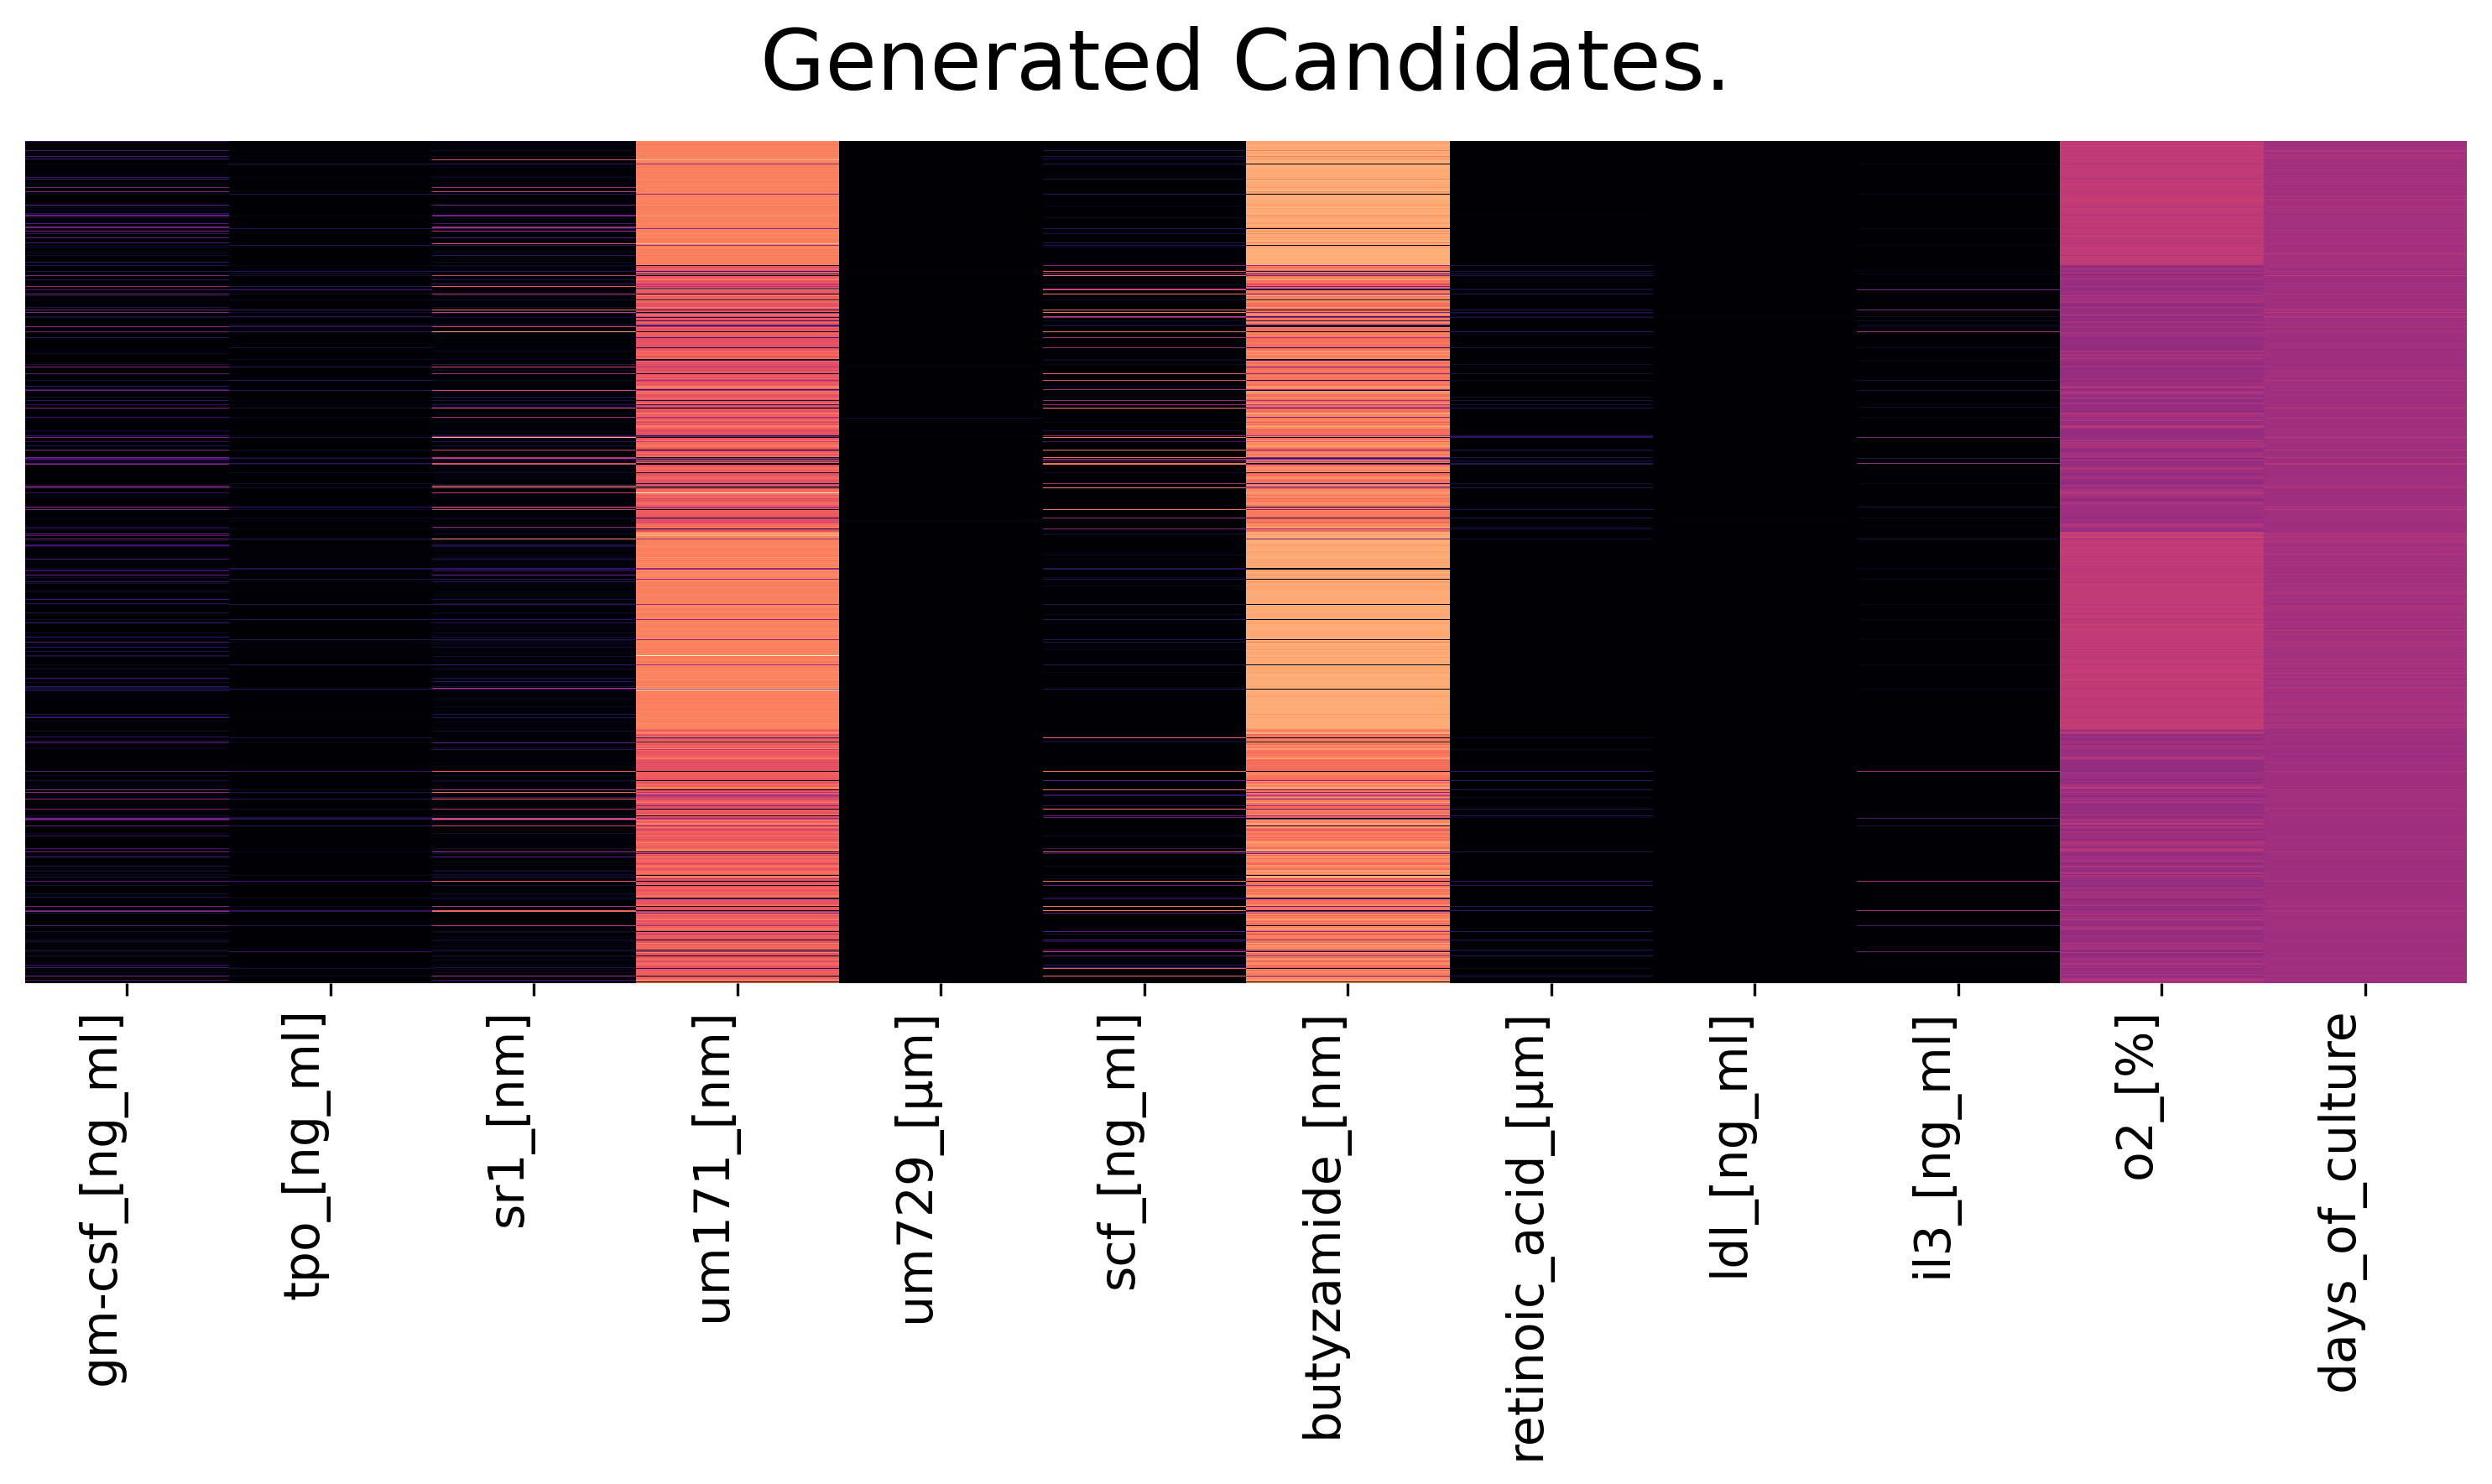

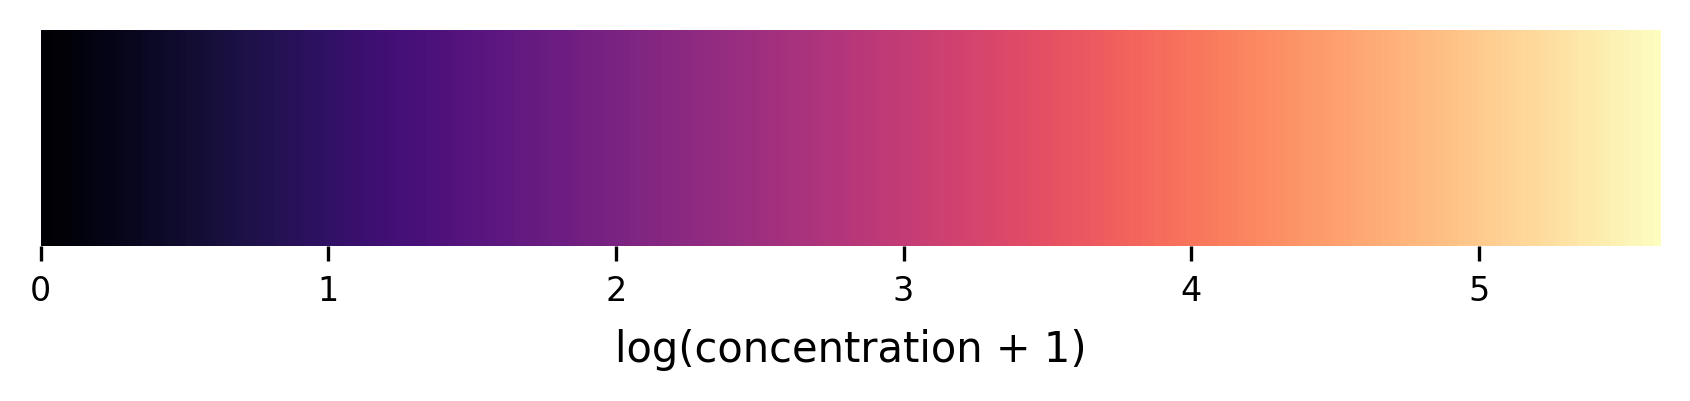

In [ ]:
# --- Your existing heatmap code (slightly adjusted) ---
filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
mgk_enriching_mask = (filtered_candidates_df_new["late_MgkPro_prop"] > 0.15)
filtered_candidates_df_new = filtered_candidates_df_new[mgk_enriching_mask]

filtered_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1))

# Compute min/max for consistent colorbar range (optional)
vmin = filtered_concs.min().min()
vmax = filtered_concs.max().max()

# Create the main heatmap (but we won't save its colorbar)
plt.figure(figsize=(10, 6), dpi=300)
ax = sns.heatmap(
    filtered_concs,
    annot=False,
    fmt='.2f',
    linewidths=0.00,
    linecolor='black',
    cmap="magma",
    cbar=False,                     # disable the default colorbar
    vmin=vmin, vmax=vmax            # keep consistent range
)
ax.set_yticklabels([])
ax.tick_params(axis='y', left=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=14)
plt.title('Generated Candidates.', fontsize=24, pad=15)
plt.tight_layout()
plt.savefig('output/filtered_concentrations_heatmap_new_data.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Create a separate, standalone colorbar (fat and short) ---
fig_cbar = plt.figure(figsize=(6, 1.2), dpi=300)   # wide figure, short height → "fat and short"
ax_cbar = fig_cbar.add_axes([0.05, 0.2, 0.9, 0.6])  # [left, bottom, width, height] – adjust as needed

# Create a ScalarMappable with the same colormap and normalization
norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='magma')   # use the same colormap as in heatmap
sm.set_array([])

# Draw the colorbar horizontally
cbar = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)
cbar.ax.tick_params(labelsize=8)

# Remove any extra spines or decorations
ax_cbar.set_frame_on(False)

# Save the standalone colorbar
fig_cbar.savefig('output/heatmap_colorbar_separate_new_data.png', bbox_inches='tight', dpi=300)
plt.show()


## Panel F: Comparison Before/After Having Seen Sakurai.

### Plot Histograms of CT Proportions Overlaid.

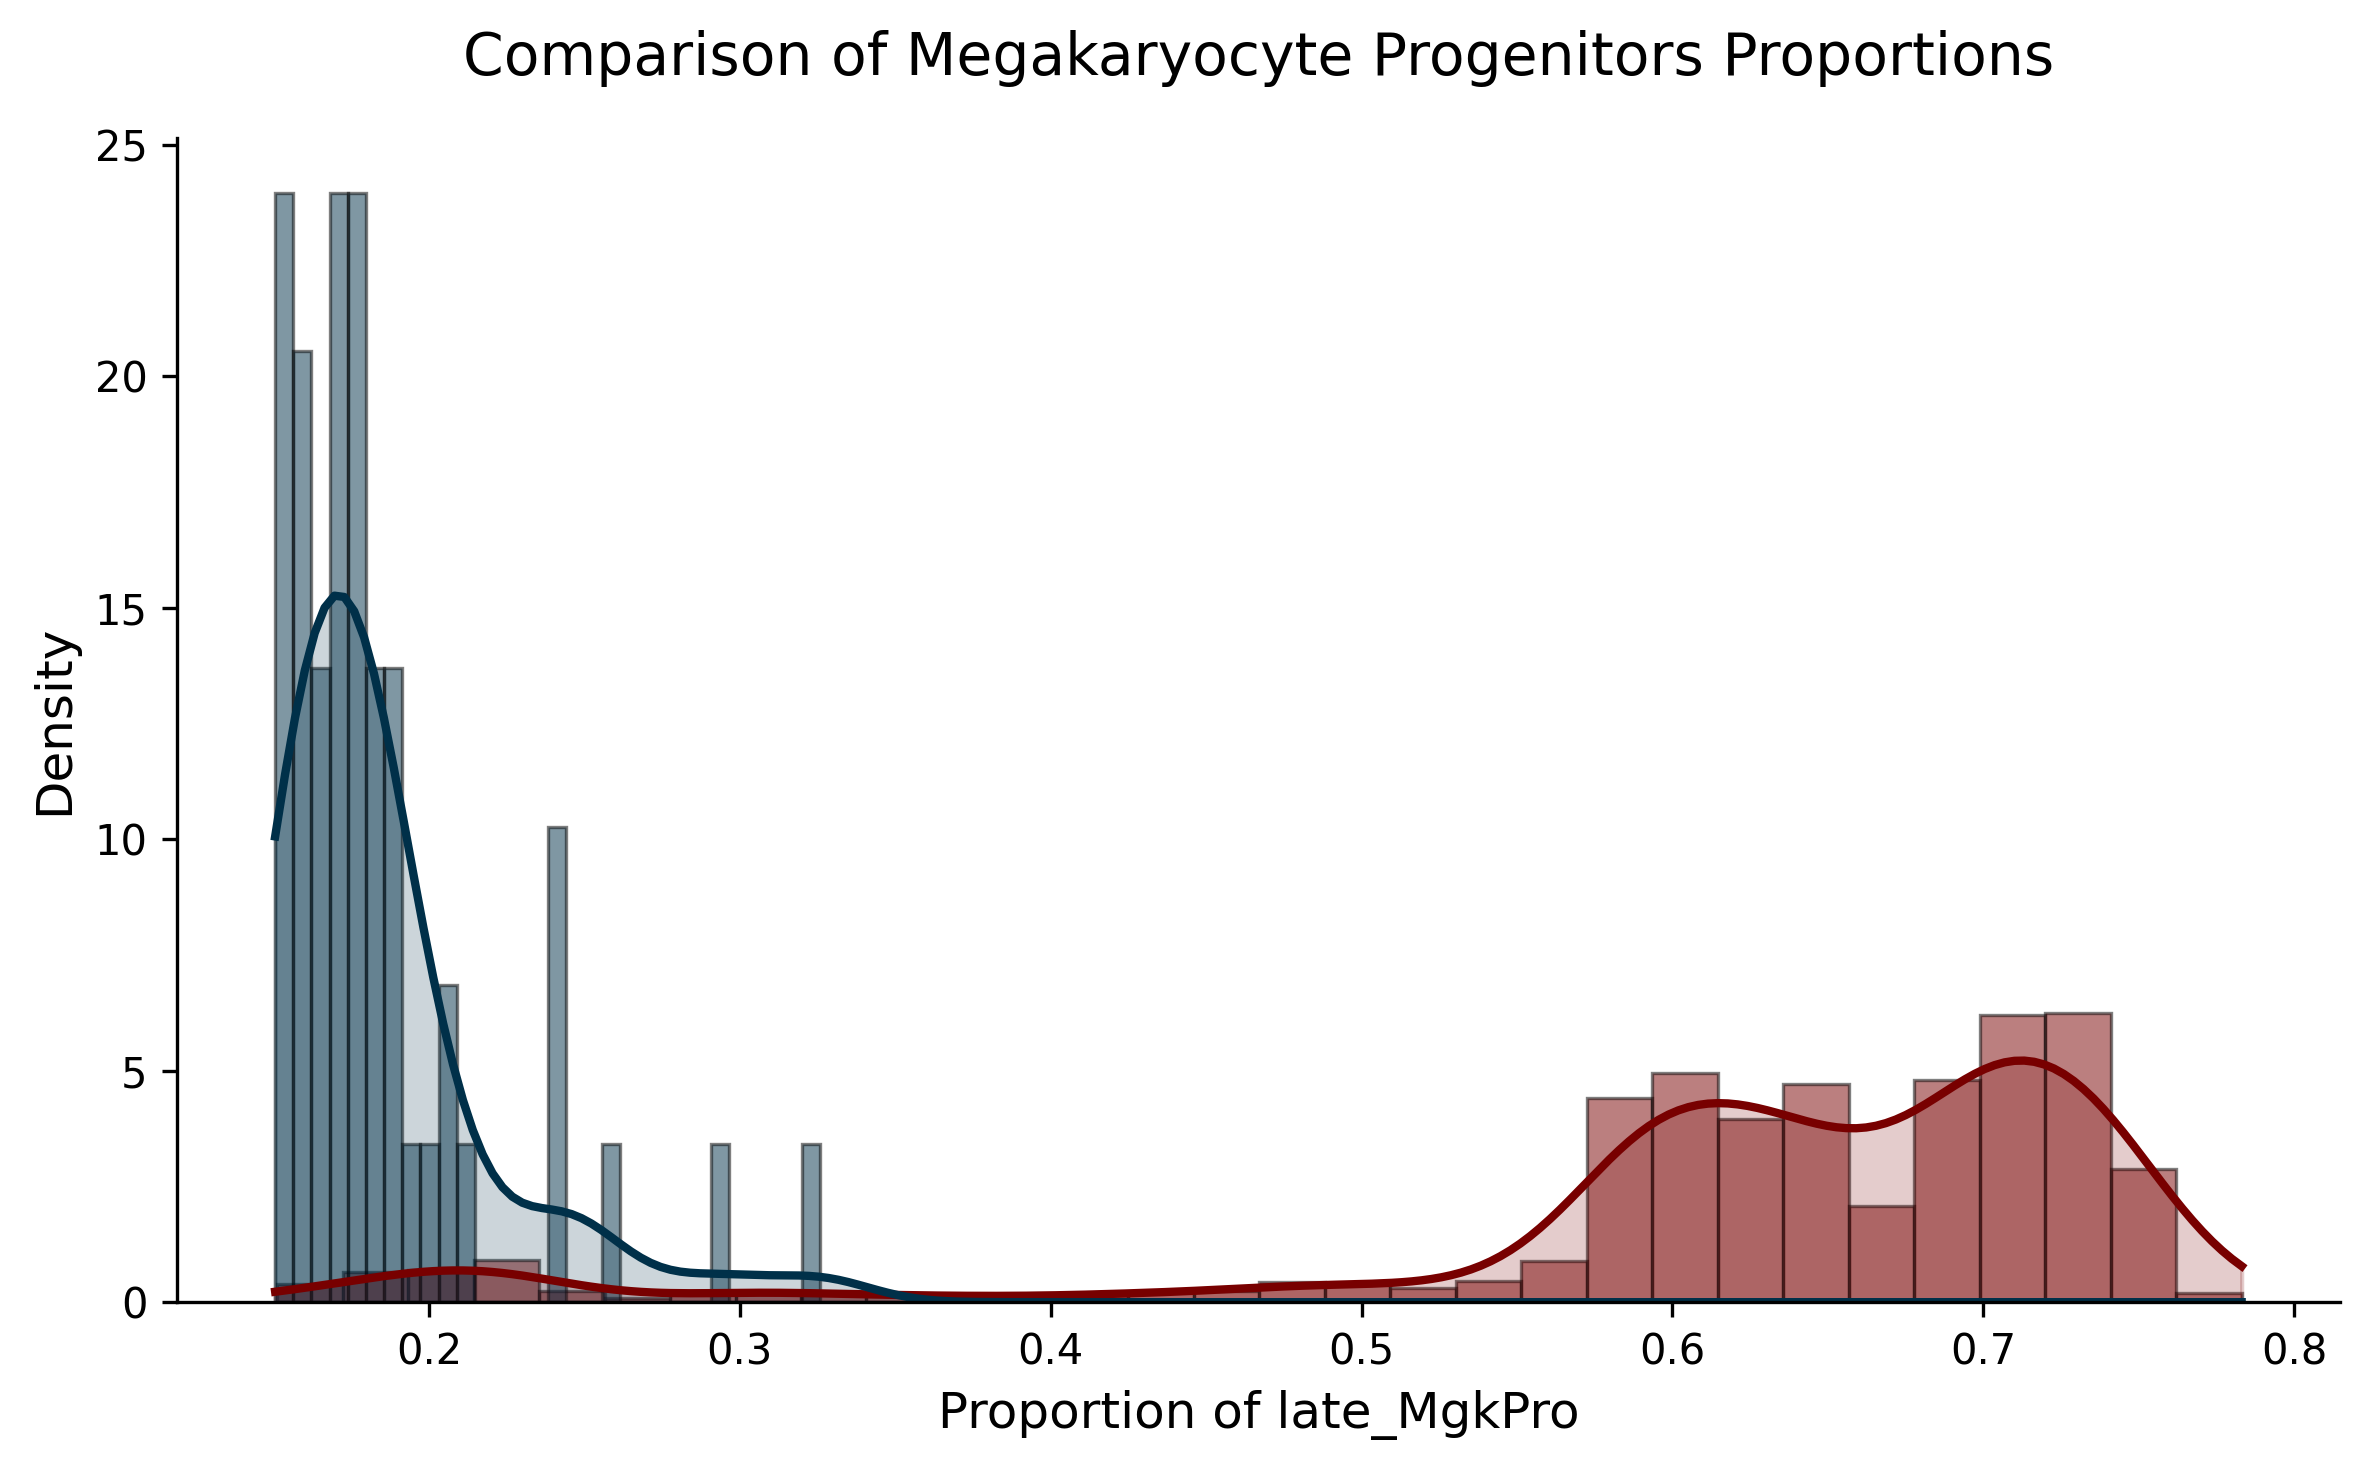

/tmp/ipykernel_859914/3218794492.py:67: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=palette[0], alpha=0.5, edgecolor='black', label='new'),
/tmp/ipykernel_859914/3218794492.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=palette[3], alpha=0.5, edgecolor='black', label='old')


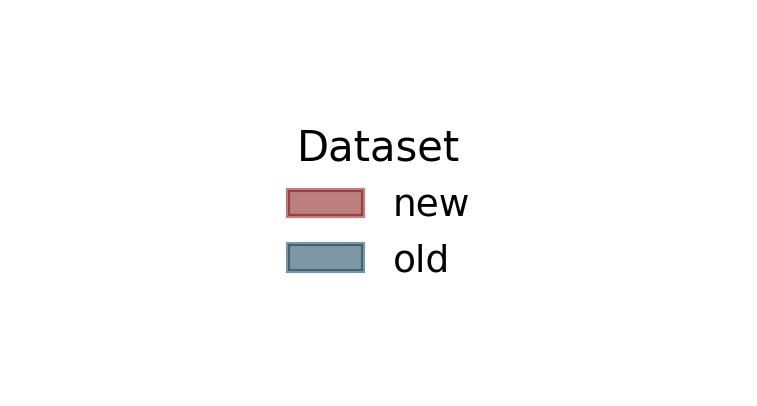

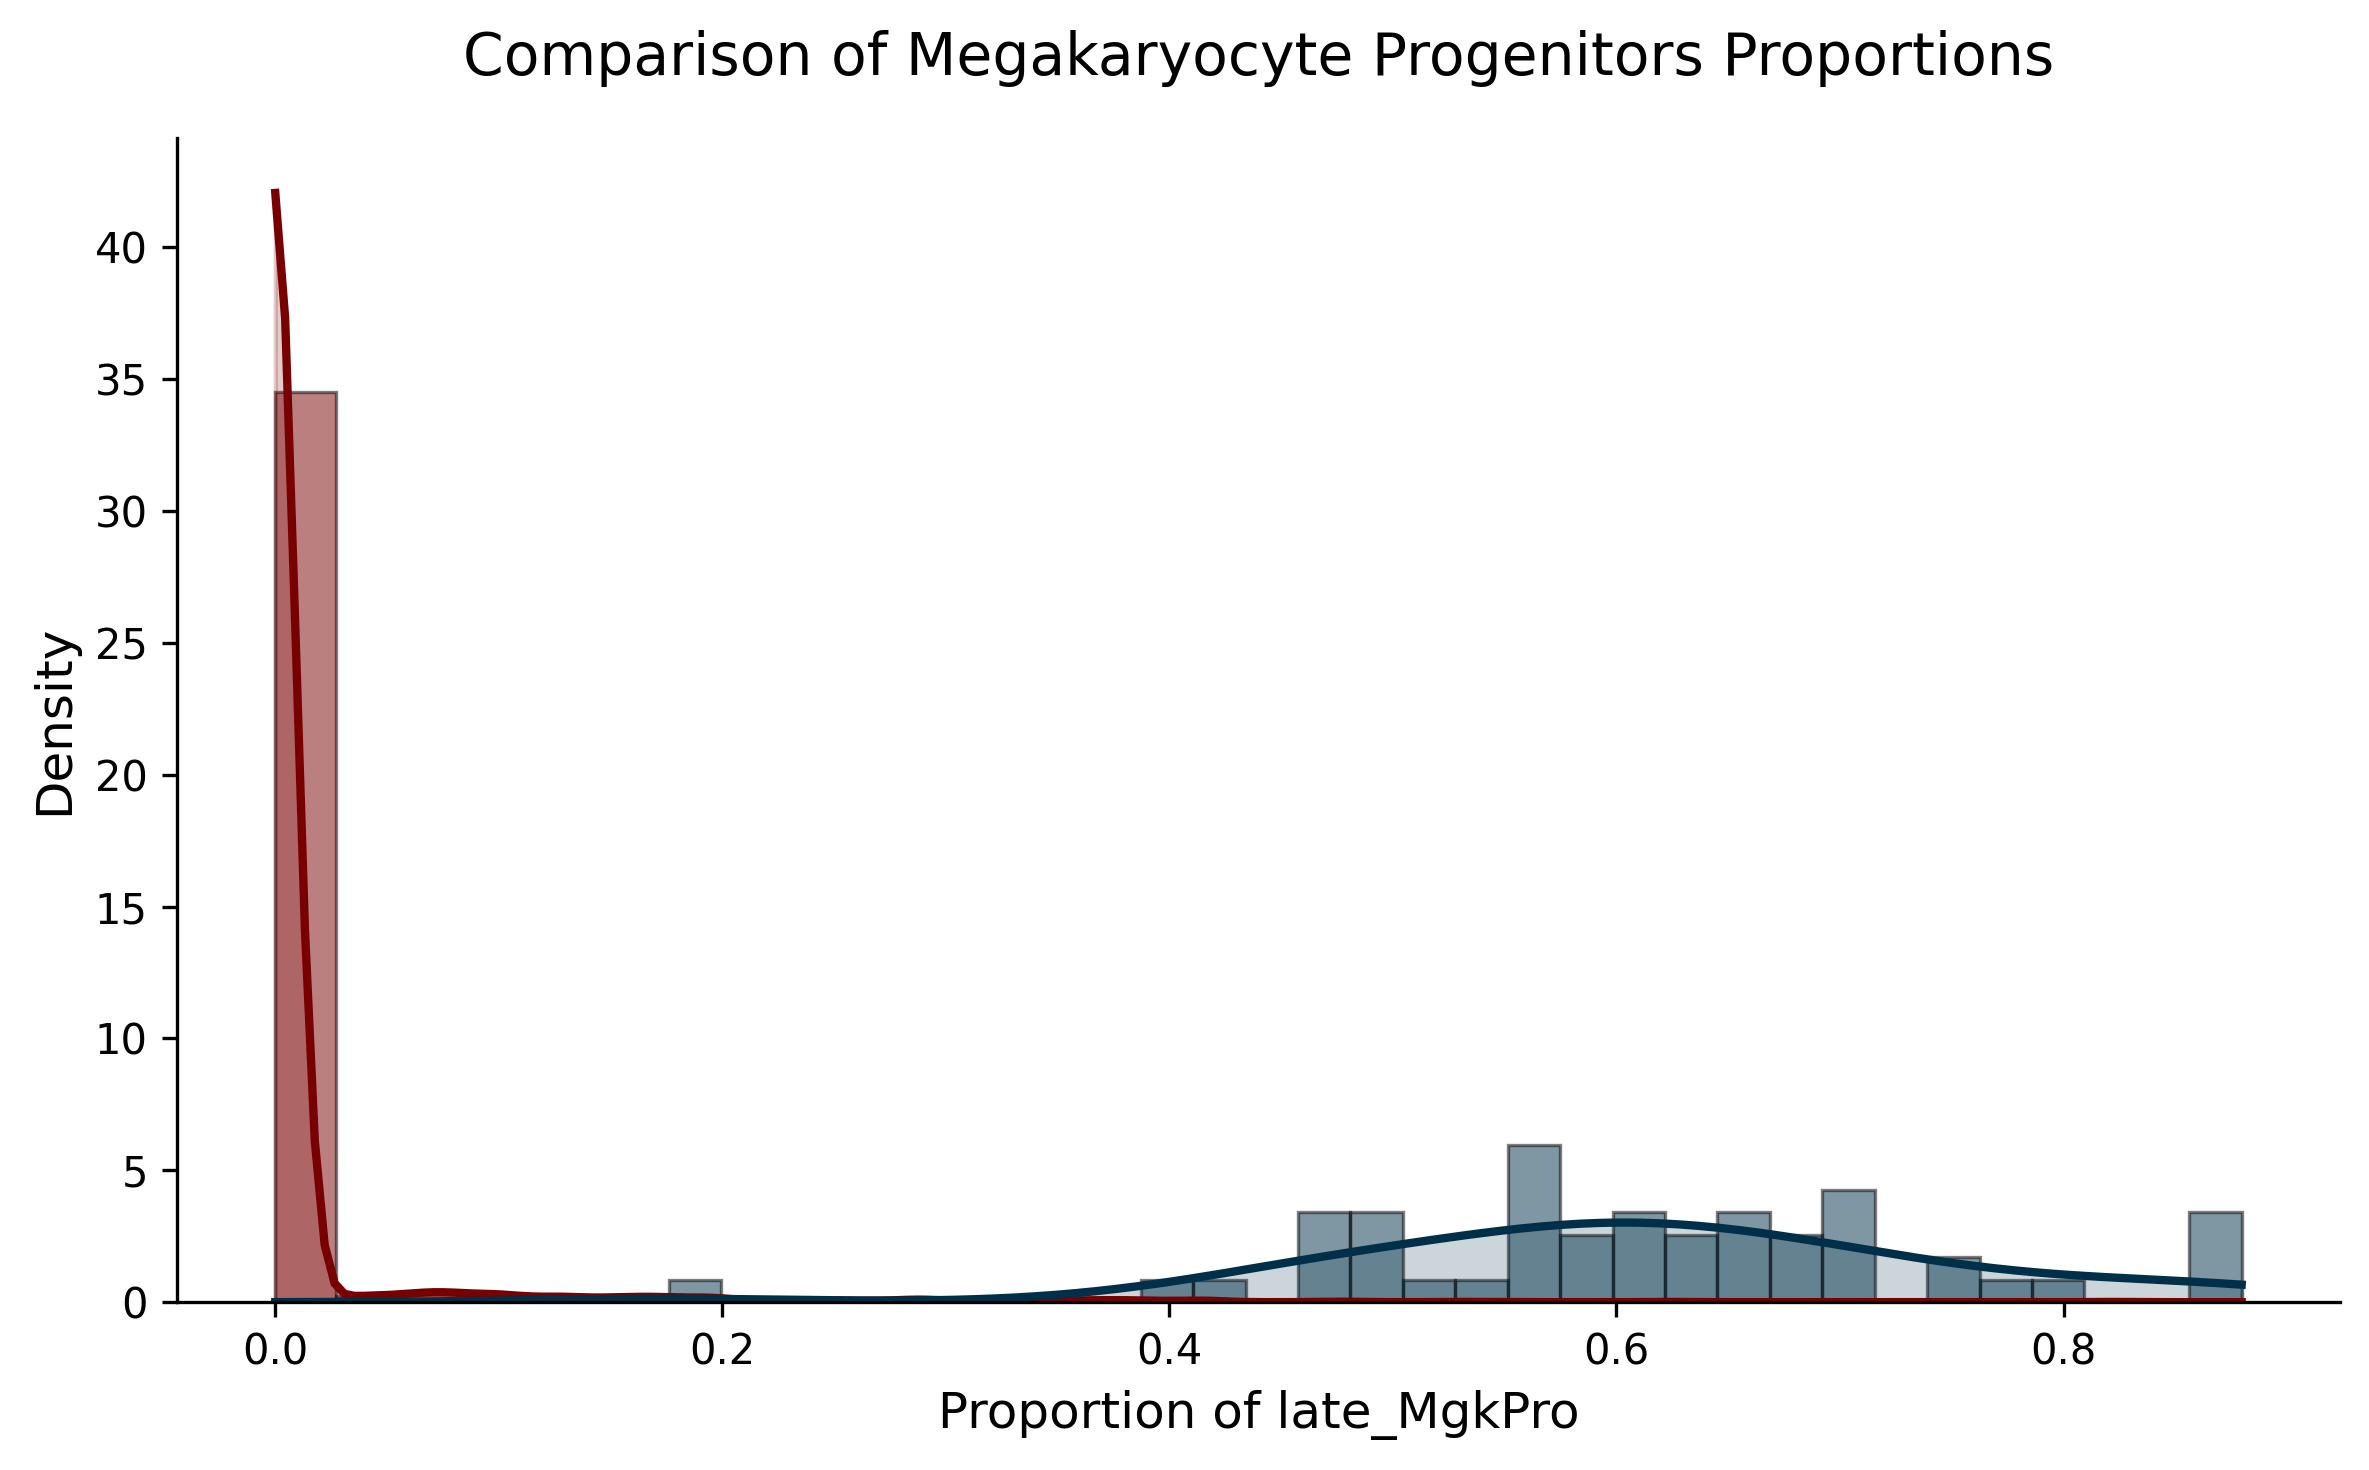

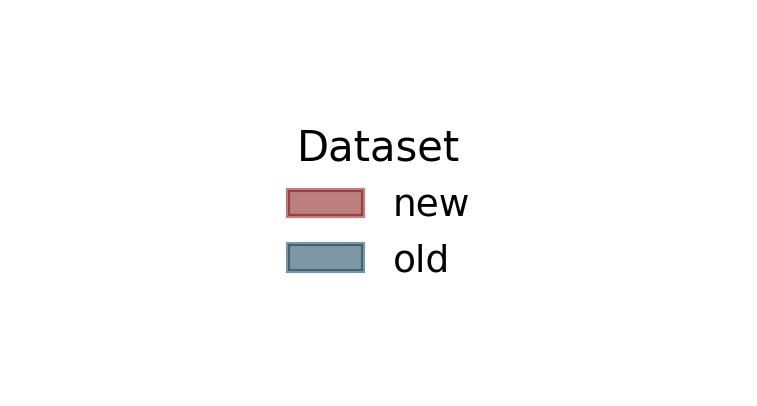

In [ ]:
# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']
cols_list = ['late_MgkPro_prop', 'target_ct_loss_std']

for col in cols_list:
        # Data

        filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
        mgk_enriching_mask = (filtered_candidates_df["late_MgkPro_prop"] > 0.15)
        filtered_candidates_df = filtered_candidates_df[mgk_enriching_mask]

        filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
        mgk_enriching_mask = (filtered_candidates_df_new["late_MgkPro_prop"] > 0.15)
        filtered_candidates_df_new = filtered_candidates_df_new[mgk_enriching_mask]

        data_new = filtered_candidates_df_new[col].dropna()
        data_old = filtered_candidates_df[col].dropna()

        # Density histograms (area = 1)
        bins = 30
        hist_new, bin_edges_new = np.histogram(data_new, bins=bins, density=True)
        hist_old, bin_edges_old = np.histogram(data_old, bins=bins, density=True)

        bin_centers_new = (bin_edges_new[:-1] + bin_edges_new[1:]) / 2
        bin_centers_old = (bin_edges_old[:-1] + bin_edges_old[1:]) / 2
        bin_width_new = np.diff(bin_edges_new)[0]
        bin_width_old = np.diff(bin_edges_old)[0]

        # Create main plot
        plt.figure(figsize=(8, 5), dpi=300)

        # Bar histograms
        plt.bar(bin_centers_new, hist_new, width=bin_width_new,
                color=palette[0], alpha=0.5, edgecolor='black', linewidth=0.8,
                label='new', align='center')
        plt.bar(bin_centers_old, hist_old, width=bin_width_old,
                color=palette[3], alpha=0.5, edgecolor='black', linewidth=0.8,
                label='old', align='center')

        # KDE estimation
        kde_new = stats.gaussian_kde(data_new)
        kde_old = stats.gaussian_kde(data_old)
        x_grid = np.linspace(min(data_new.min(), data_old.min()),
                        max(data_new.max(), data_old.max()), 200)

        # KDE lines and fills
        plt.plot(x_grid, kde_new(x_grid), color=palette[0], linewidth=2, label='_nolegend_')
        plt.plot(x_grid, kde_old(x_grid), color=palette[3], linewidth=2, label='_nolegend_')
        plt.fill_between(x_grid, kde_new(x_grid), color=palette[0], alpha=0.2)
        plt.fill_between(x_grid, kde_old(x_grid), color=palette[3], alpha=0.2)

        # Labels and title
        plt.xlabel('Proportion of late_MgkPro', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.title('Comparison of Megakaryocyte Progenitors Proportions', fontsize=14, pad=15)

        sns.despine()
        plt.tight_layout()
        plt.savefig(f'output/enrichment_unfiltered_{col}_histogram_with_kde.png', bbox_inches='tight', dpi=300)
        plt.show()

        # ------------------------------------------------------------------
        # Save legend separately with explicit colored patches
        # ------------------------------------------------------------------
        # Create custom legend handles (rectangles with the exact bar colors)
        legend_handles = [
        mpatches.Patch(color=palette[0], alpha=0.5, edgecolor='black', label='new'),
        mpatches.Patch(color=palette[3], alpha=0.5, edgecolor='black', label='old')
        ]

        # Create a separate figure for the legend
        fig_legend = plt.figure(figsize=(3, 1.5), dpi=300)
        ax_legend = fig_legend.add_subplot(111)
        ax_legend.axis('off')
        ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                        fontsize=9, loc='center', frameon=False)
        fig_legend.savefig(f'output/{col}_legend_separate.png', bbox_inches='tight', dpi=300)
        plt.show()


### Scatter Plot Performance v Uncertainty.

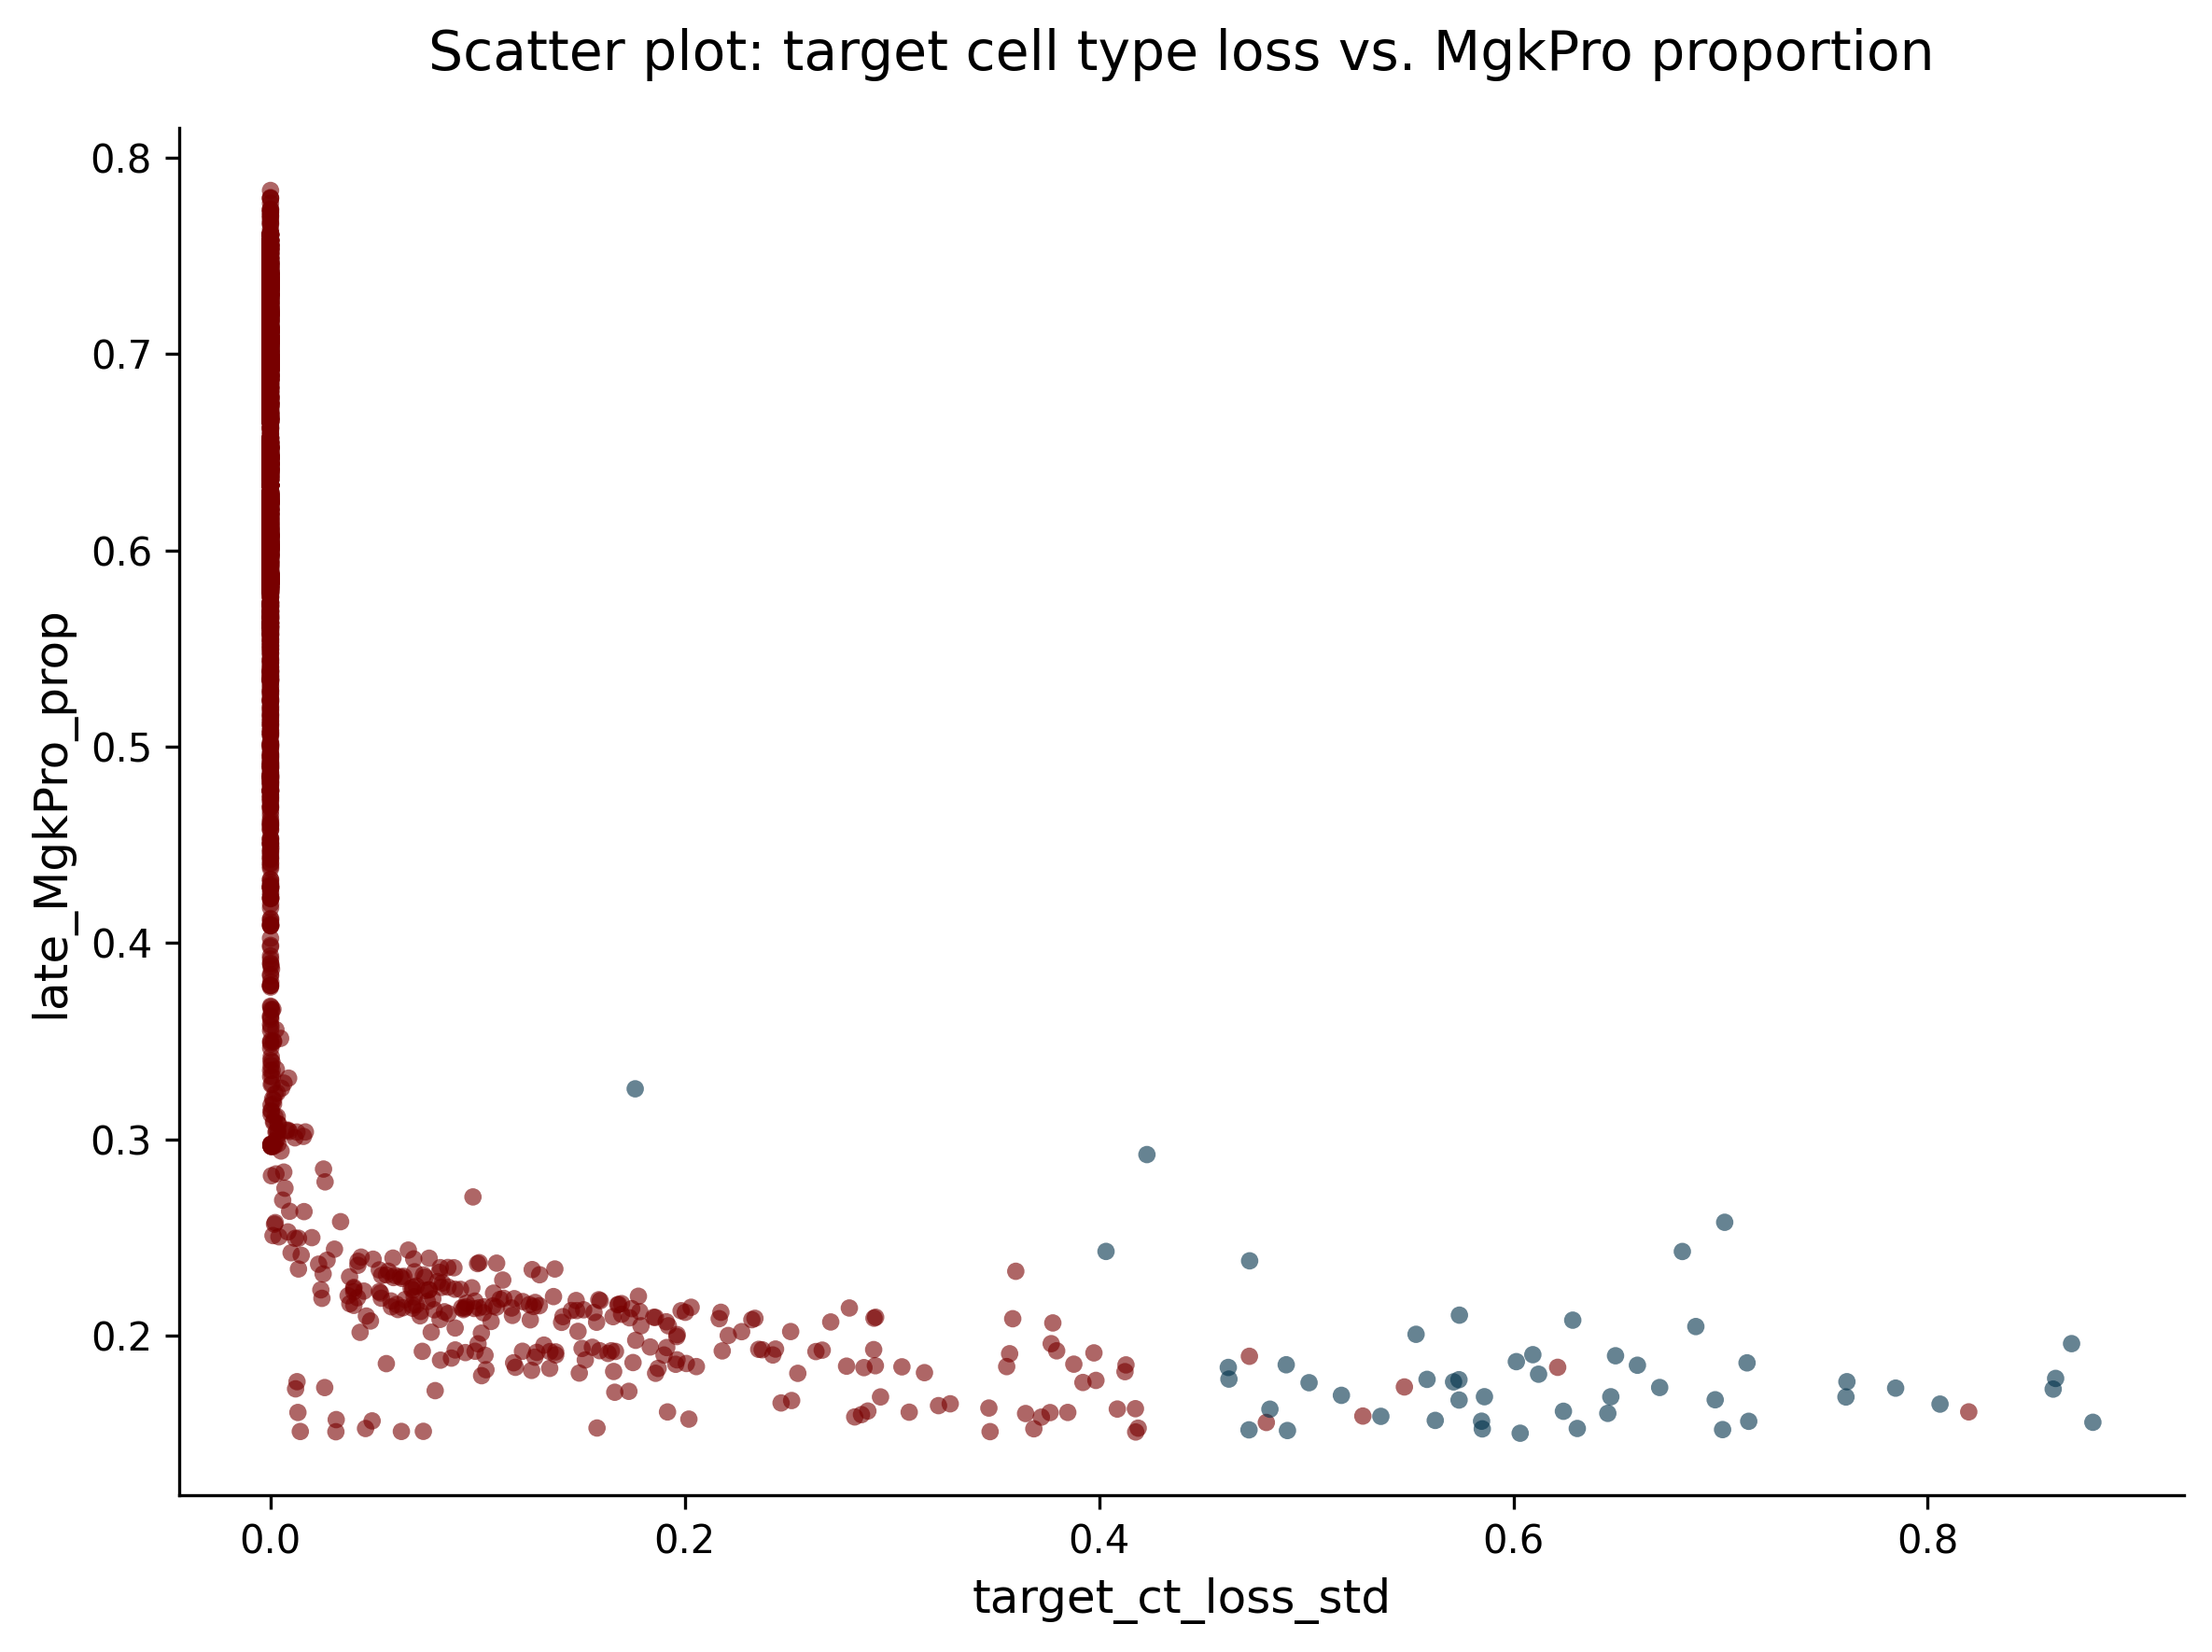

/tmp/ipykernel_859914/1450415175.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_map['new'], alpha=0.6, label='new', edgecolor='none'),
/tmp/ipykernel_859914/1450415175.py:57: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_map['old'], alpha=0.6, label='old', edgecolor='none')


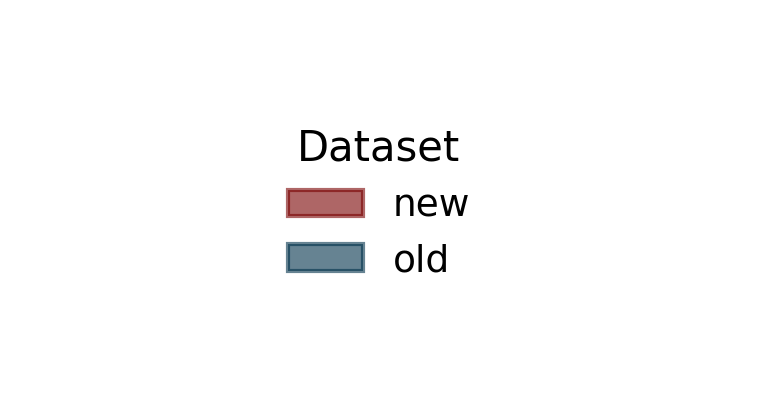

In [ ]:
# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# Prepare the two datasets with a common label column
data_new = filtered_candidates_df_new.copy()
data_new['dataset'] = 'new'
data_old = filtered_candidates_df.copy()
data_old['dataset'] = 'old'

# Combine into one DataFrame
combined = pd.concat([data_new, data_old], ignore_index=True)

# Extract columns (drop any rows with missing values)
x_col = 'target_ct_loss_std'
y_col = 'late_MgkPro_prop'
plot_df = combined[[x_col, y_col, 'dataset']].dropna()

# Define color mapping
color_map = {'new': palette[0], 'old': palette[3]}

# ------------------------------------------------------------
# 1. Main scatter plot (NO legend)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=300)

# Plot each dataset separately to control colors without legend
for dataset, color in color_map.items():
    subset = plot_df[plot_df['dataset'] == dataset]
    plt.scatter(subset[x_col], subset[y_col],
                c=color, alpha=0.6, s=20, edgecolor='none',
                label=dataset)          # label assigned but legend=False later

# Remove legend if automatically added (though we didn't call legend, but to be safe)
plt.legend().remove()   # ensures no legend appears

# Labels and title
plt.xlabel('target_ct_loss_std', fontsize=12)
plt.ylabel('late_MgkPro_prop', fontsize=12)
plt.title('Scatter plot: target cell type loss vs. MgkPro proportion', fontsize=14, pad=15)

sns.despine()
plt.tight_layout()
plt.savefig('output/scatter_target_ct_loss_std_vs_MgkPro_prop.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Save the legend separately (explicit colored patches)
# ------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=color_map['new'], alpha=0.6, label='new', edgecolor='none'),
    mpatches.Patch(color=color_map['old'], alpha=0.6, label='old', edgecolor='none')
]

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(3, 1.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                 fontsize=9, loc='center', frameon=False)
fig_legend.savefig('output/scatter_legend_separate.png', bbox_inches='tight', dpi=300)
plt.show()


### Plot Conditions in PCA Space.

In [ ]:

# Your palette
palette = ['#780000', '#c1121f', '#fdf0d5', '#003049', '#669bbc']

# ----------------------------------------------------------------------
# 1. Prepare real condition vectors (one per experiment)
# ----------------------------------------------------------------------
real_conds = adata_full.obs[protocol_cols].astype(float).values
exp_nums = adata_full.obs["experiment_number"].values

unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)
real_matrix = np.log1p(real_matrix)          # log(1 + concentration)
exp_labels = np.array(exp_labels)

# ----------------------------------------------------------------------
# 2. Prepare candidate condition vectors (old and new)
# ----------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
filtered_candidates_df = filtered_candidates_df[filtered_candidates_df["late_MgkPro_prop"] > 0.15]
old_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1)).values

filtered_candidates_df_new = candidates_df_new[candidates_df_new["passes_constraints:all"]]
filtered_candidates_df_new = filtered_candidates_df_new[filtered_candidates_df_new["late_MgkPro_prop"] > 0.15]
new_concs = filtered_candidates_df_new[protocol_cols].map(lambda e: math.log(e + 1)).values

# ----------------------------------------------------------------------
# Helper function to plot (single panel + two panels) given PCA projections
# ----------------------------------------------------------------------
def plot_pca_projections(real_pca, old_pca, new_pca, pca_obj, star_coords, method_name):
    """Creates single-panel and two-panel scatter plots, saves them and a separate legend."""
    
    # ---- Single panel ----
    plt.figure(figsize=(8, 6), dpi=300)
    plt.scatter(real_pca[:, 0], real_pca[:, 1],
                c='lightgrey', alpha=0.6, s=30, edgecolor='none')
    plt.scatter(old_pca[:, 0], old_pca[:, 1],
                c=palette[3], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    plt.scatter(new_pca[:, 0], new_pca[:, 1],
                c=palette[0], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        plt.scatter(star_coords[0], star_coords[1],
                    marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    plt.xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title(f'PCA ({method_name})', fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'output/pca_{method_name}_single.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ---- Two panels ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)
    # Left: real + old
    ax_left.scatter(real_pca[:, 0], real_pca[:, 1],
                    c='lightgrey', alpha=0.6, s=30, edgecolor='none')
    ax_left.scatter(old_pca[:, 0], old_pca[:, 1],
                    c=palette[3], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_left.scatter(star_coords[0], star_coords[1],
                        marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    ax_left.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_left.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_left.set_title(f'Old candidates ({method_name})', fontsize=12)
    # Right: real + new
    ax_right.scatter(real_pca[:, 0], real_pca[:, 1],
                     c='lightgrey', alpha=0.6, s=30, edgecolor='none')
    ax_right.scatter(new_pca[:, 0], new_pca[:, 1],
                     c=palette[0], alpha=0.7, s=40, edgecolor='black', linewidth=0.5)
    if star_coords is not None:
        ax_right.scatter(star_coords[0], star_coords[1],
                         marker='*', s=300, c='gold', edgecolor='black', linewidth=1, zorder=5)
    ax_right.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax_right.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax_right.set_title(f'New candidates ({method_name})', fontsize=12)
    sns.despine(ax=ax_left); sns.despine(ax=ax_right)
    plt.tight_layout()
    plt.savefig(f'output/pca_{method_name}_twopanel.png', dpi=300, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------------
# 3. Find coordinates of experiment 210 (we need real_pca for both methods later)
#    We'll compute star_coords after PCA for each method.
# ----------------------------------------------------------------------
# Helper to get star_coords given real_pca and exp_labels
def get_star_coords(real_pca, exp_labels):
    if 210 in exp_labels:
        idx = np.where(exp_labels == 210)[0][0]
        return real_pca[idx]
    return None

# ----------------------------------------------------------------------
# Approach A: Joint PCA (fit on all data)
# ----------------------------------------------------------------------
all_data = np.vstack([real_matrix, old_concs, new_concs])
pca_joint = PCA(n_components=2)
all_pca_joint = pca_joint.fit_transform(all_data)

n_real = real_matrix.shape[0]
n_old = old_concs.shape[0]
real_pca_joint = all_pca_joint[:n_real]
old_pca_joint = all_pca_joint[n_real:n_real+n_old]
new_pca_joint = all_pca_joint[n_real+n_old:]

star_coords_joint = get_star_coords(real_pca_joint, exp_labels)

plot_pca_projections(real_pca_joint, old_pca_joint, new_pca_joint,
                     pca_joint, star_coords_joint, method_name="joint")

# ----------------------------------------------------------------------
# Approach B: PCA fit only on real data, then transform candidates
# ----------------------------------------------------------------------
pca_realonly = PCA(n_components=2)
real_pca_realonly = pca_realonly.fit_transform(real_matrix)          # shape (n_real,2)
old_pca_realonly = pca_realonly.transform(old_concs)                 # project old
new_pca_realonly = pca_realonly.transform(new_concs)                 # project new
star_coords_realonly = get_star_coords(real_pca_realonly, exp_labels)

plot_pca_projections(real_pca_realonly, old_pca_realonly, new_pca_realonly,
                     pca_realonly, star_coords_realonly, method_name="realonly")

# ----------------------------------------------------------------------
# 4. Save the legend separately (same for both methods)
# ----------------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color='lightgrey', alpha=0.6, label='Real experiments', edgecolor='none'),
    mpatches.Patch(color=palette[3], alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color=palette[0], alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
    mpatches.Patch(color='gold', label='Exp 210', edgecolor='black', linewidth=1)
]
fig_legend = plt.figure(figsize=(4, 2.5), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset / Condition',
                 title_fontsize=10, fontsize=9, loc='center', frameon=False)
fig_legend.savefig('output/pca_legend_separate.png', bbox_inches='tight', dpi=300)
plt.close(fig_legend)

print("All plots saved:")
print("  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png")
print("  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png")
print("  - Legend: output/pca_legend_separate.png")

All plots saved:
  - Joint PCA: output/pca_joint_single.png, output/pca_joint_twopanel.png
  - Real-only PCA: output/pca_realonly_single.png, output/pca_realonly_twopanel.png
  - Legend: output/pca_legend_separate.png


/tmp/ipykernel_859914/1772283376.py:140: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='lightgrey', alpha=0.6, label='Real experiments', edgecolor='none'),
/tmp/ipykernel_859914/1772283376.py:141: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=palette[3], alpha=0.7, label='Old candidates', edgecolor='black', linewidth=0.5),
/tmp/ipykernel_859914/1772283376.py:142: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=palette[0], alpha=0.7, label='New candidates', edgecolor='black', linewidth=0.5),
/tmp/ipykernel_859914/1772283376.py:143: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='gold', label='Exp 210', edgecolor='black', linewidth=1)
